In [1]:
# Data manipulation and numerical operations
import numpy as np  # Essential for numerical operations
import pandas as pd  # For data manipulation and analysis

# Visualization libraries
import matplotlib.pyplot as plt  # General-purpose plotting
import seaborn as sns  # Statistical data visualization based on matplotlib
import plotly.express as px  # Interactive visualization, a more modern and flexible alternative to matplotlib
from matplotlib import gridspec 

# Machine learning libraries
from sklearn.model_selection import train_test_split  # Split dataset into train and test
from sklearn.preprocessing import StandardScaler  # For feature scaling
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline  # To streamline transformations and models in a pipeline
from sklearn.metrics import accuracy_score, confusion_matrix  # Common performance metrics

# Machine learning models
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier  # Gradient boosting algorithm with tree-based learning
from catboost import CatBoostClassifier  # Highly effective for categorical data
# from lightgbm import LGBMClassifier  # Efficient gradient boosting with tree-based learning

# OS-related operations
import os  # Operating system-related utilities
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 437.2 kB/s eta 0:03:52
   ---------------------------------------- 0.5/101.7 MB 437.2 kB/s eta 0:03:52
   ---------------------------------------- 0.8/101.7 MB 439.8 kB/s eta 0:03:50
   ---------------------------------------- 0.8/101


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
air_quality = pd.read_csv('environmental_design_dataset.csv')

In [76]:
#first few rows of dataset
air_quality.head()

,Timestamp,Sensor_ID,Zone,Temp,Humidity,CO2,PM25,Illuminance,Sound,PMV,PPD,DA,AAI,NDVI,Comfort_Score,AQI_Class
0,2024-01-01 00:00:00,S1,Room1,27.025712,47.764121,550.076658,26.502355,374.689685,44.074750,-0.230611,9.612227,37.468969,0.440747,0.590214,0.923130,Good
1,2024-01-01 00:00:00,S2,Room2,25.046120,42.021709,710.304919,15.071982,384.835844,41.317915,-0.130608,14.612158,38.483584,0.413179,0.326628,0.956464,Good
2,2024-01-01 00:00:00,S3,Room3,25.970129,48.071642,579.443408,21.093931,412.939968,37.560666,-0.010097,9.201943,41.293997,0.375607,0.338391,0.996634,Good
3,2024-01-01 01:00:00,S1,Room1,24.184103,53.923401,634.833416,25.220088,370.466555,52.164802,-0.446075,16.921499,37.046655,0.521648,0.595466,0.851308,Good
4,2024-01-01 01:00:00,S2,Room2,25.668486,51.190183,608.683784,8.474166,474.304387,50.166251,-0.168455,8.369094,47.430439,0.501663,0.695018,0.943848,Moderate


In [77]:
#number of rows, number of columns in dataset
air_quality.shape

(6480, 16)

In [78]:
#check dataset's info
air_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Timestamp      6480 non-null   object 
 1   Sensor_ID      6480 non-null   object 
 2   Zone           6480 non-null   object 
 3   Temp           6480 non-null   float64
 4   Humidity       6480 non-null   float64
 5   CO2            6480 non-null   float64
 6   PM25           6480 non-null   float64
 7   Illuminance    6480 non-null   float64
 8   Sound          6480 non-null   float64
 9   PMV            6480 non-null   float64
 10  PPD            6480 non-null   float64
 11  DA             6480 non-null   float64
 12  AAI            6480 non-null   float64
 13  NDVI           6480 non-null   float64
 14  Comfort_Score  6480 non-null   float64
 15  AQI_Class      6480 non-null   object 
dtypes: float64(12), object(4)
memory usage: 810.1+ KB


In [80]:
# Rename columns
air_quality = passengers.rename(columns={
    'PM25': 'Particulate_Matter_25',
    'PMV': 'Predicted_Mean_Vote',
    'PPD': 'Predicted_Percentage_Dissatisfied',
    'DA': 'Daylight_Autonomy',
    'AAI': 'Acoustic_Annoyance_Index', 
    'NDVI': 'Normalized_Difference_Vegetation_Index' 
})

In [81]:
#show the columns title
air_quality.columns

Index(['Timestamp', 'Sensor_ID', 'Zone', 'Temp', 'Humidity', 'CO2',
       'Particulate_Matter_25', 'Illuminance', 'Sound', 'Predicted_Mean_Vote',
       'Predicted_Percentage_Dissatisfied', 'Daylight_Autonomy',
       'Acoustic_Annoyance_Index', 'Normalized_Difference_Vegetation_Index',
       'Comfort_Score', 'AQI_Class'],
      dtype='object')

In [82]:
#check the missing value
air_quality.isna().sum().sort_values(ascending=False)

Timestamp                                 0
Sensor_ID                                 0
Zone                                      0
Temp                                      0
Humidity                                  0
CO2                                       0
Particulate_Matter_25                     0
Illuminance                               0
Sound                                     0
Predicted_Mean_Vote                       0
Predicted_Percentage_Dissatisfied         0
Daylight_Autonomy                         0
Acoustic_Annoyance_Index                  0
Normalized_Difference_Vegetation_Index    0
Comfort_Score                             0
AQI_Class                                 0
dtype: int64

In [83]:
#check for dupliate values
air_quality.duplicated().sum()

0

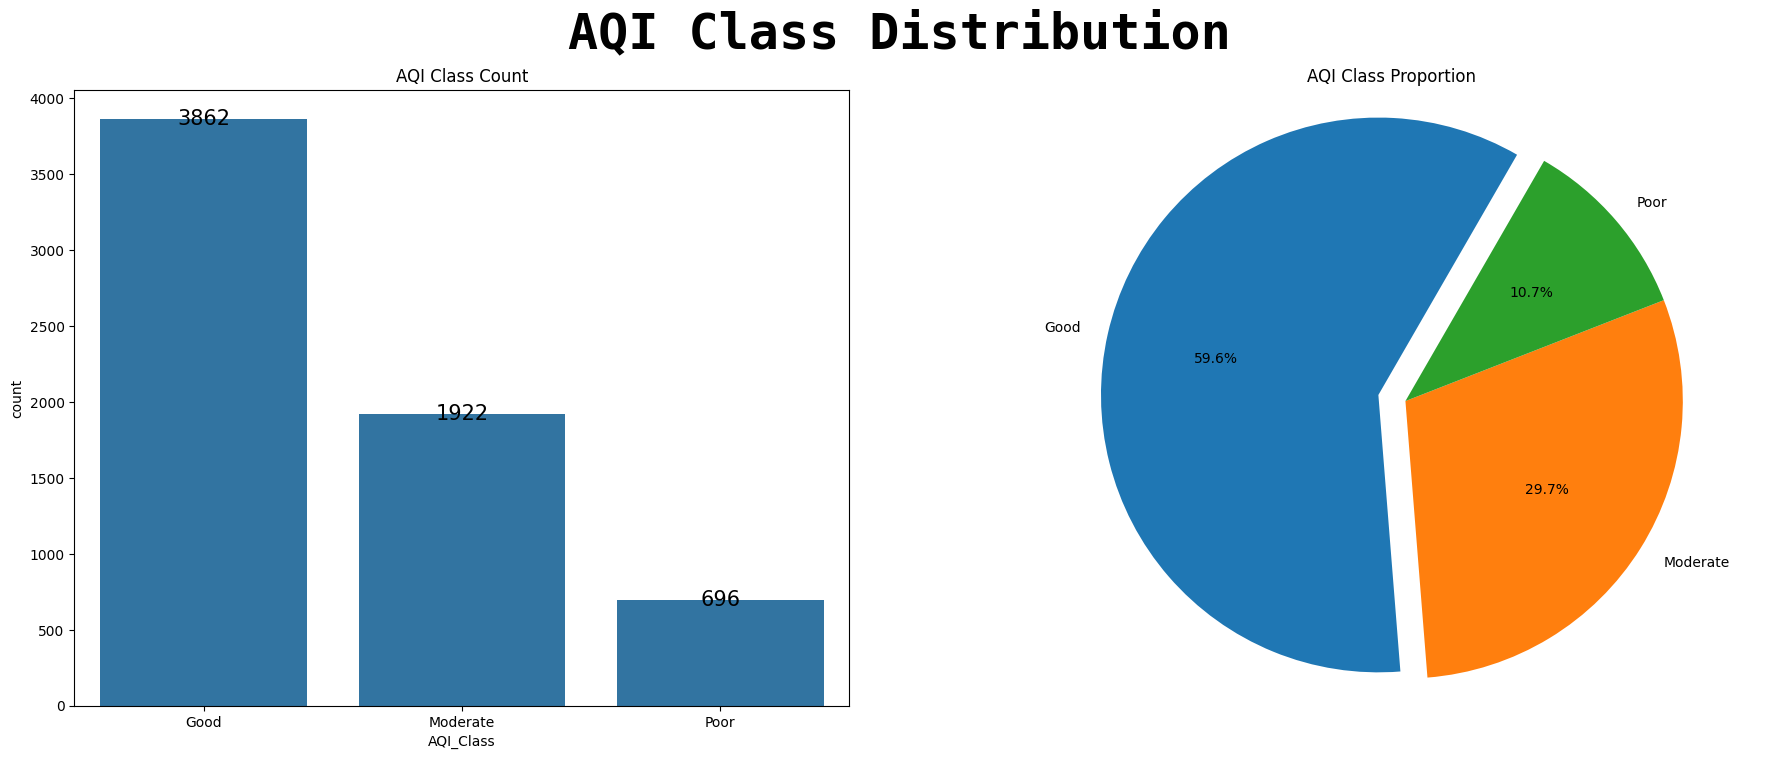

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming df is your DataFrame
fig = plt.figure(figsize=(22, 8))
plt.suptitle('AQI Class Distribution', weight="bold", fontsize=36, fontname='monospace')
grid = gridspec.GridSpec(nrows=1, ncols=2, figure=fig)

# Bar plot
ax1 = fig.add_subplot(grid[0, :1])
ax1.set_title('AQI Class Count')
sns.countplot(x='AQI_Class', data=air_quality, ax=ax1, order=air_quality['AQI_Class'].value_counts().index)

for index, value in enumerate(air_quality['AQI_Class'].value_counts().values):
    ax1.annotate(value, xy=(index, value), ha='center', va='center', fontsize=15)

# Pie chart
ax2 = fig.add_subplot(grid[0, 1:])
ax2.set_title('AQI Class Proportion')
labels = air_quality['AQI_Class'].value_counts().index
values = air_quality['AQI_Class'].value_counts().values
explode = [0.1 if i == values.argmax() else 0 for i in range(len(values))]
ax2.pie(values, labels=labels, autopct='%1.1f%%', explode=explode, startangle=60)
ax2.axis('equal')

plt.show()

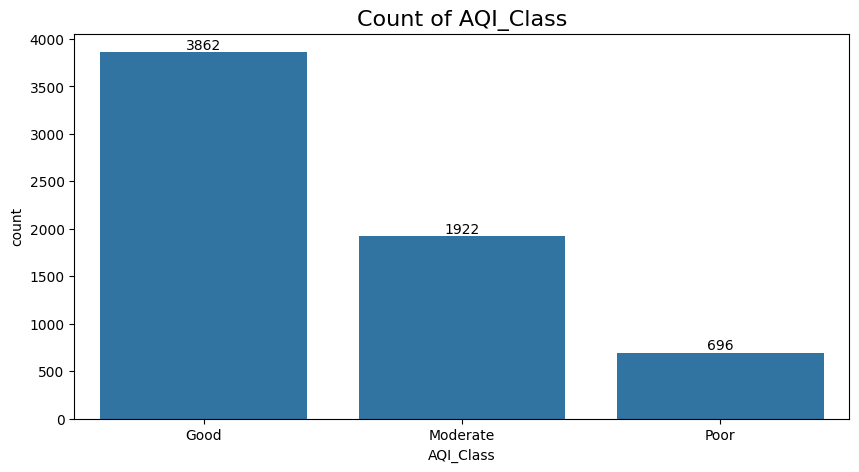

In [86]:
categorical_cols = ['AQI_Class']

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=air_quality, x=col, order=air_quality[col].value_counts().index)
    plt.title(f'Count of {col}', fontsize=16)
    plt.xticks(rotation=45 if col == 'Sensor_ID' else 0)
    for p in plt.gca().patches:
        plt.gca().annotate(f'{int(p.get_height())}', 
                           (p.get_x() + p.get_width()/2., p.get_height()),
                           ha='center', va='center', fontsize=10, color='black', xytext=(0,5),
                           textcoords='offset points')
    plt.show()

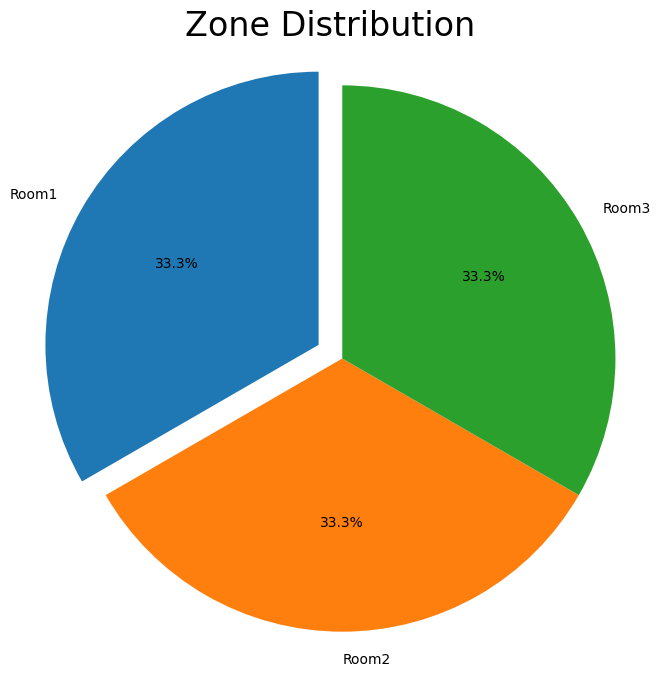

In [87]:
plt.figure(figsize=(8, 8))
plt.title('Zone Distribution', fontsize=24)

labels = air_quality['Zone'].value_counts().index
values = air_quality['Zone'].value_counts().values
explode = [0.1 if i == values.argmax() else 0 for i in range(len(values))]

plt.pie(values, labels=labels, autopct='%1.1f%%', explode=explode, startangle=90)
plt.axis('equal')
plt.show()

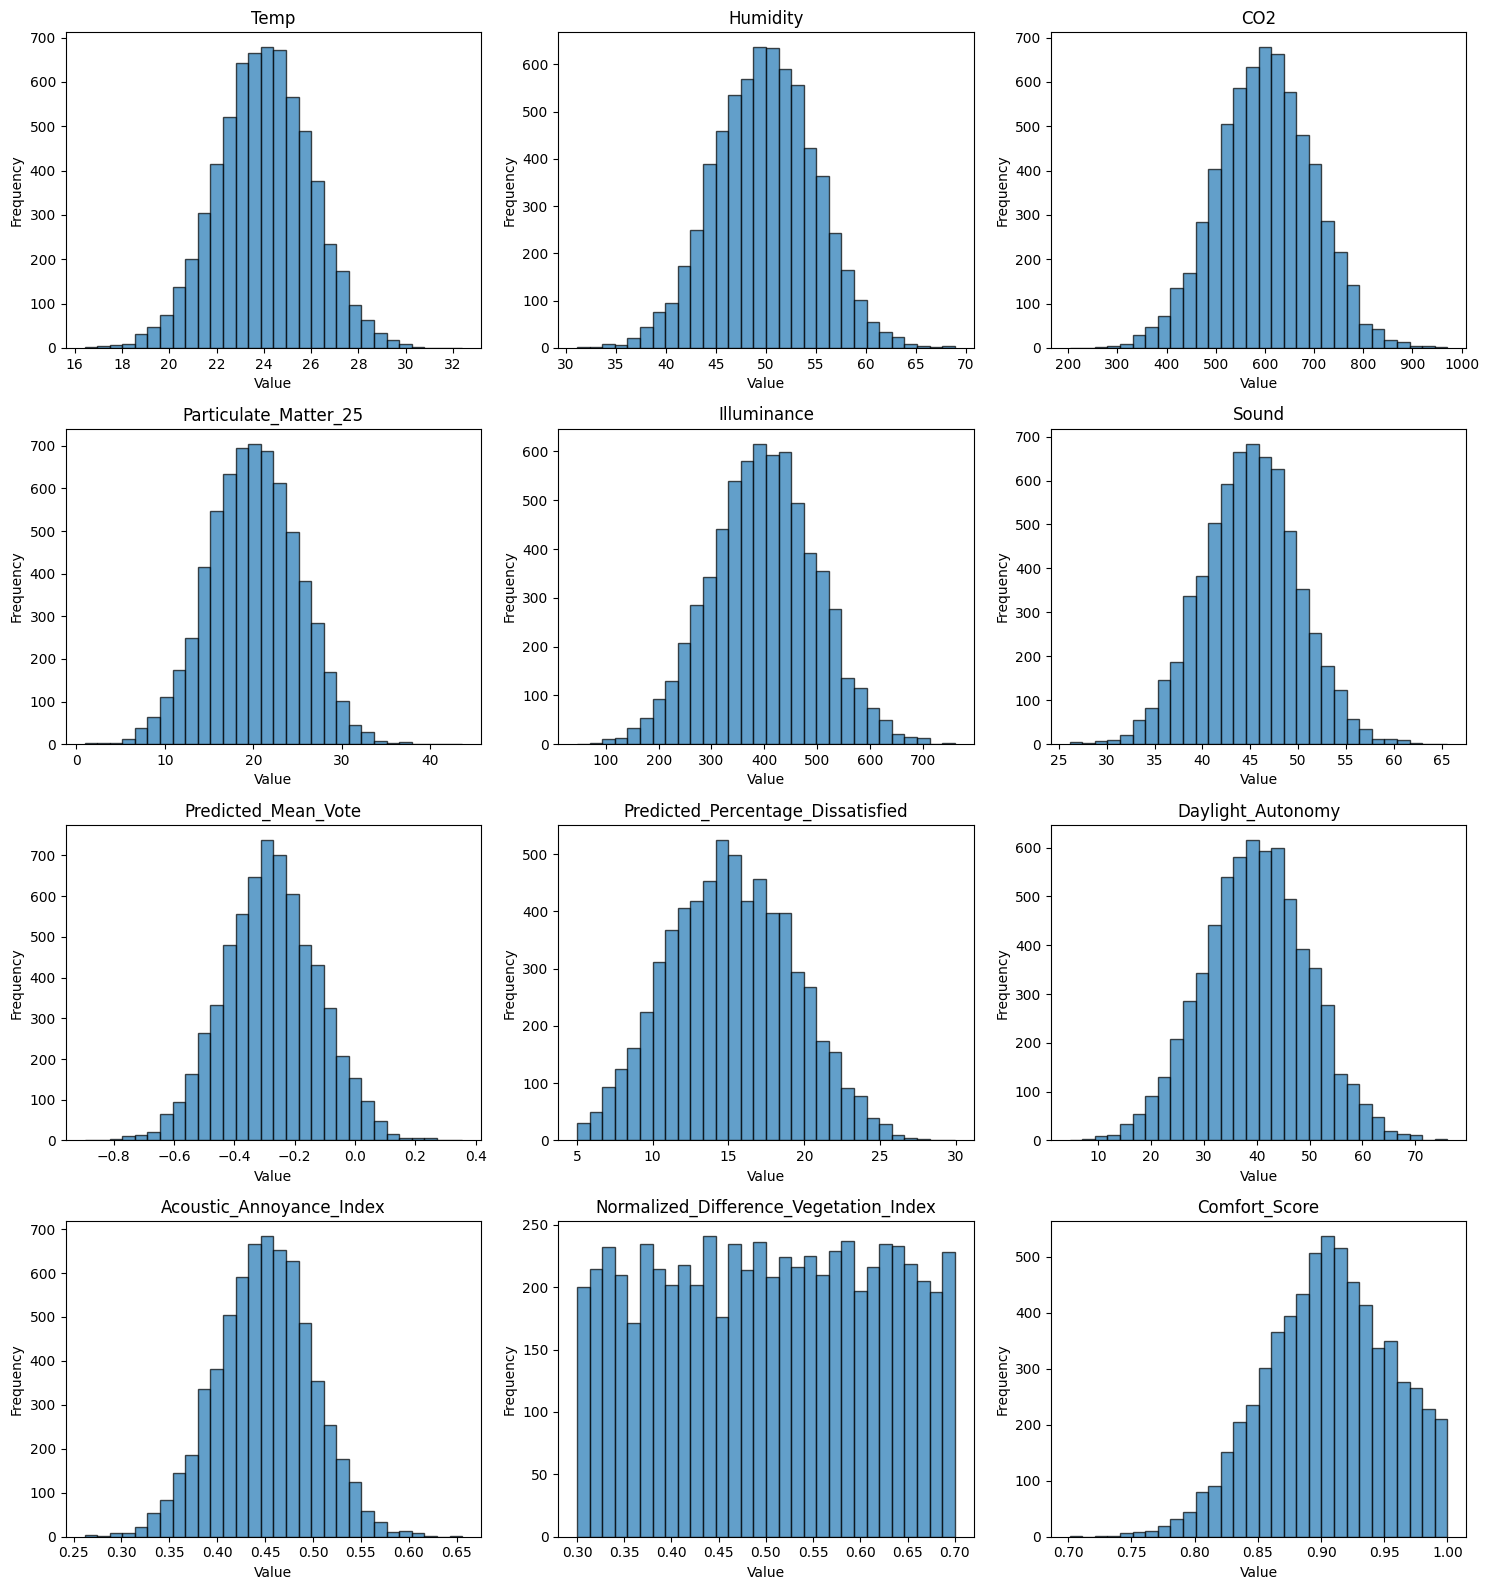

In [88]:
# List all numeric columns (exclude Timestamp, Sensor_ID, Zone, AQI_Class)
numeric_cols = ['Temp', 'Humidity', 'CO2', 'Particulate_Matter_25', 'Illuminance',
                'Sound', 'Predicted_Mean_Vote', 'Predicted_Percentage_Dissatisfied',
                'Daylight_Autonomy', 'Acoustic_Annoyance_Index',
                'Normalized_Difference_Vegetation_Index', 'Comfort_Score']

# Set up subplots
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(air_quality[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

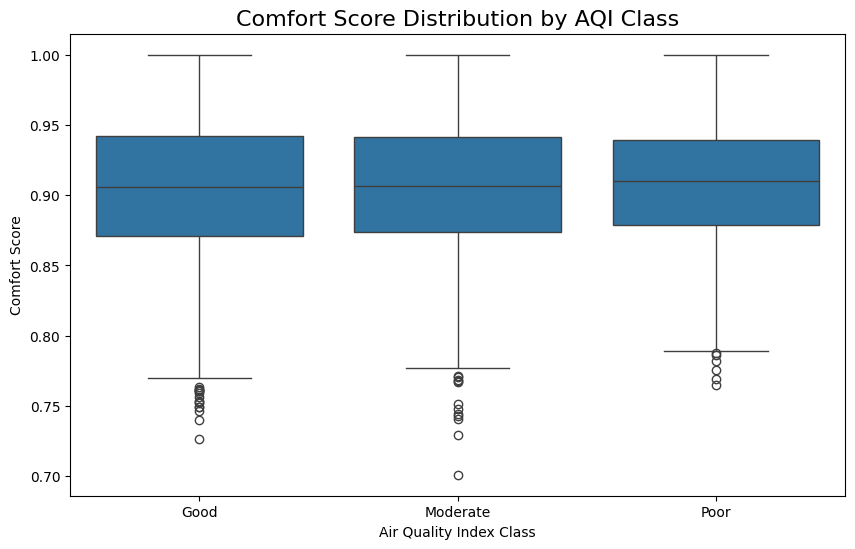

In [89]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=air_quality, x='AQI_Class', y='Comfort_Score', order=['Good', 'Moderate', 'Poor'])
plt.title('Comfort Score Distribution by AQI Class', fontsize=16)
plt.xlabel('Air Quality Index Class')
plt.ylabel('Comfort Score')
plt.show()

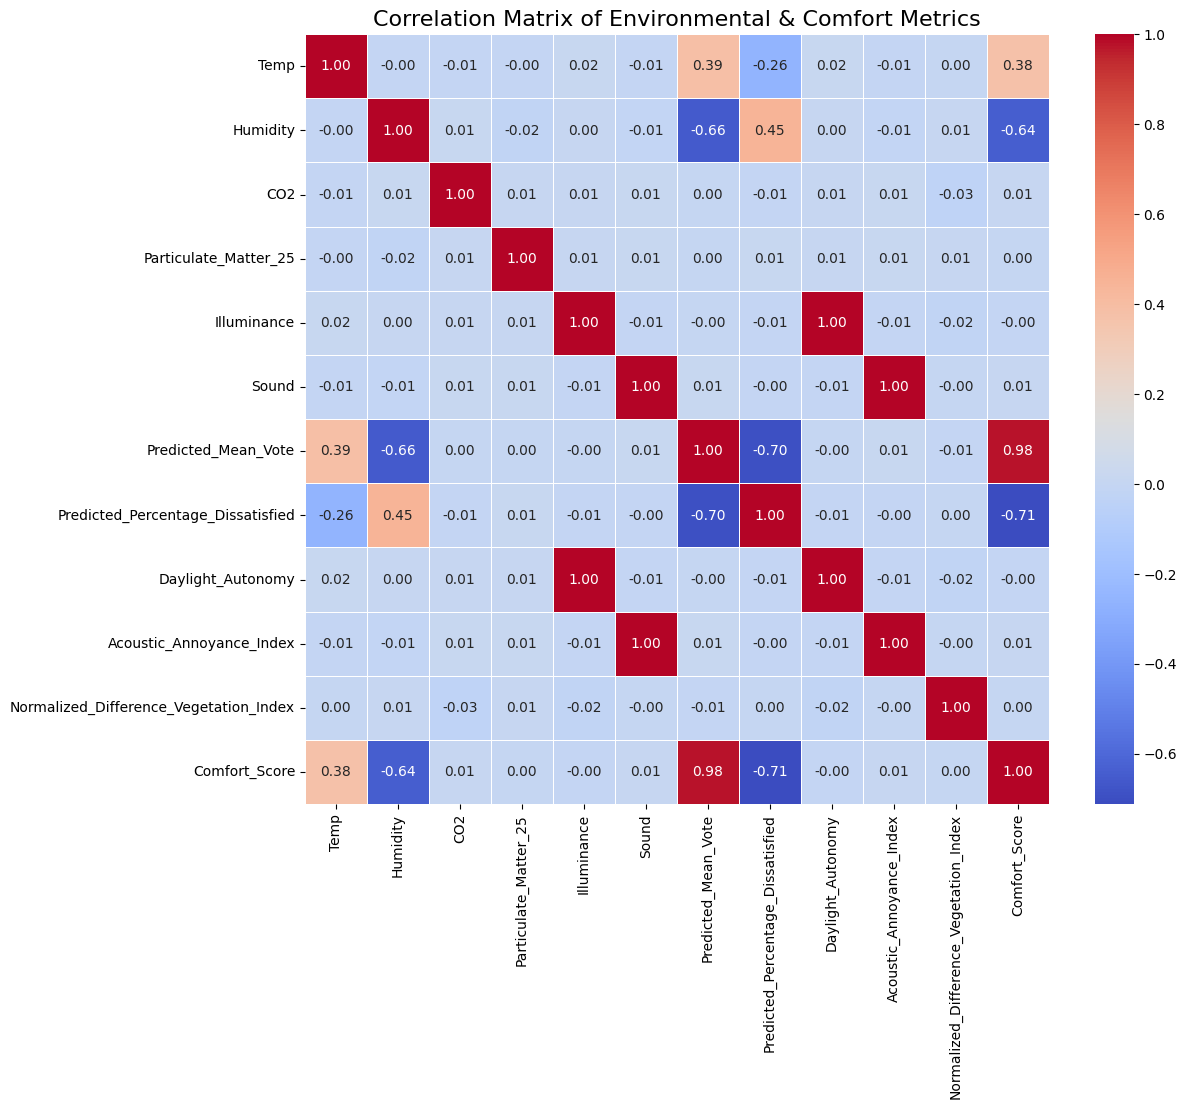

In [90]:
plt.figure(figsize=(12, 10))
corr = air_quality[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Environmental & Comfort Metrics', fontsize=16)
plt.show()

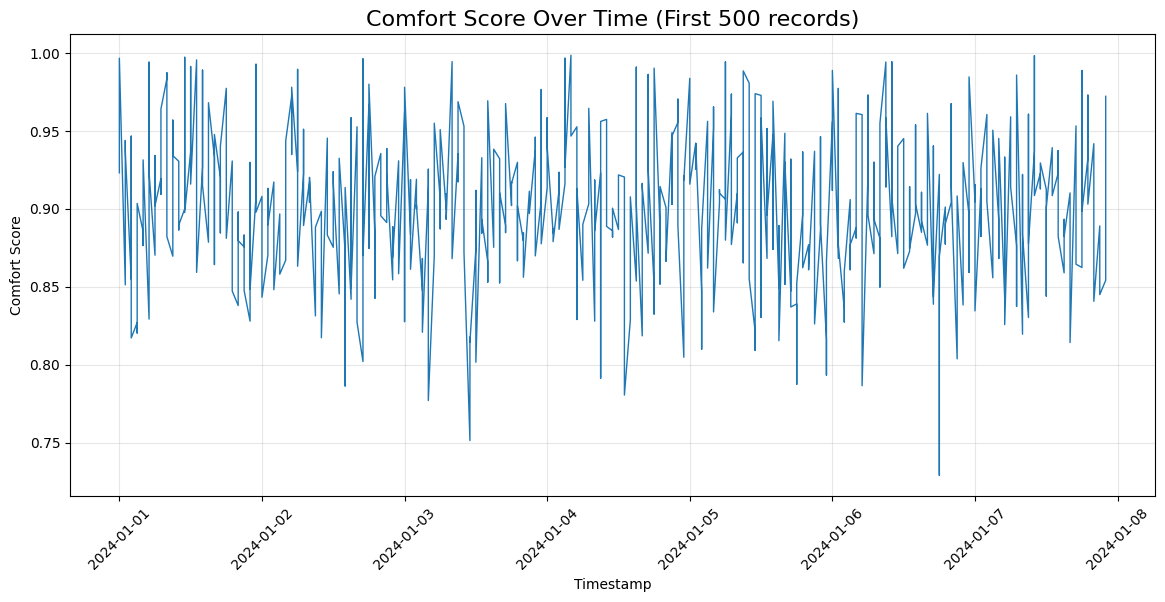

In [91]:
# Convert Timestamp to datetime if not already
air_quality['Timestamp'] = pd.to_datetime(air_quality['Timestamp'])

# Plot Comfort Score over time (first 500 points for clarity)
plt.figure(figsize=(14, 6))
plt.plot(air_quality['Timestamp'][:500], air_quality['Comfort_Score'][:500], linewidth=1)
plt.title('Comfort Score Over Time (First 500 records)', fontsize=16)
plt.xlabel('Timestamp')
plt.ylabel('Comfort Score')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [93]:
# Identify categorical features based on dtype
cat_features = [feature for feature in air_quality.columns if air_quality[feature].dtype == 'object']

# Print the results
print('Number of categorical variables:', len(cat_features))
print('Names of categorical variables:', cat_features)

Number of categorical variables: 3
Names of categorical variables: ['Sensor_ID', 'Zone', 'AQI_Class']


In [94]:
#numerical features
num_features = [feature for feature in air_quality.columns if air_quality[feature].dtypes != 'O']
print('Number of numerical variables: ', len(num_features))
print('Name of numerical variables: ',num_features)

Number of numerical variables:  13
Name of numerical variables:  ['Timestamp', 'Temp', 'Humidity', 'CO2', 'Particulate_Matter_25', 'Illuminance', 'Sound', 'Predicted_Mean_Vote', 'Predicted_Percentage_Dissatisfied', 'Daylight_Autonomy', 'Acoustic_Annoyance_Index', 'Normalized_Difference_Vegetation_Index', 'Comfort_Score']


In [98]:
# Define categorical features to group by
for col in cat_features:
    cat_group = air_quality.groupby(col)['AQI_Class'].describe()
    percent = 100 * (cat_group['freq'] / cat_group['count'])
    print('*' * 65)
    print("Insights from '{}' data".format(col))
    for i in range(len(cat_group)):
        print("{}% of '{}' have AQI Class = {}".format(
            round(percent.iloc[i], 2), 
            cat_group.index[i], 
            cat_group['top'].iloc[i]
        ))
    print('*' * 65)

*****************************************************************
Insights from 'Sensor_ID' data
59.63% of 'S1' have AQI Class = Good
61.71% of 'S2' have AQI Class = Good
57.45% of 'S3' have AQI Class = Good
*****************************************************************
*****************************************************************
Insights from 'Zone' data
59.63% of 'Room1' have AQI Class = Good
61.71% of 'Room2' have AQI Class = Good
57.45% of 'Room3' have AQI Class = Good
*****************************************************************
*****************************************************************
Insights from 'AQI_Class' data
100.0% of 'Good' have AQI Class = Good
100.0% of 'Moderate' have AQI Class = Moderate
100.0% of 'Poor' have AQI Class = Poor
*****************************************************************


All zones and sensors show similar AQI distributions (57–62% Good), with Room2/S2 slightly better and Room3/S3 slightly worse. No zone is a clear outlier, suggesting building‑level factors dominate over room‑specific differences.

In [99]:
air_quality['AQI_Class'].value_counts()

AQI_Class
Good        3862
Moderate    1922
Poor         696
Name: count, dtype: int64

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def CalPercentage(air_quality, col):
    """
    Returns a DataFrame with percentage of each unique value in col.
    """
    percent_df = air_quality[col].value_counts(normalize=True).reset_index()
    percent_df.columns = [col, 'percentage']
    percent_df['percentage'] = percent_df['percentage'] * 100
    return percent_df

def Visualization(air_quality, col):
    """
    Plots:
    1. Bar chart: percentage of each category in 'col'
    2. Countplot: distribution of 'col' colored by 'AQI_Class'
    """
    df_per = CalPercentage(air_quality, col)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6))
    plt.suptitle(col, fontsize=24, fontname='monospace', weight='bold')
    plt.subplots_adjust(hspace=0.9)

    # Left: percentage barplot
    sns.barplot(x=df_per[col], y='percentage', data=df_per, ax=ax1)
    ax1.set_xticklabels(df_per[col], rotation=45)
    ax1.set_xlabel('Category', fontsize=20)
    ax1.set_ylabel('Percentage (%)', fontsize=20)

    # Right: countplot with hue = AQI_Class
    sns.countplot(x=col, data=air_quality, hue='AQI_Class', ax=ax2)
    ax2.set_xlabel(col, fontsize=20)
    ax2.set_xticklabels(air_quality[col].value_counts().index, rotation=45)
    ax2.legend(title='AQI Class')

    plt.show()

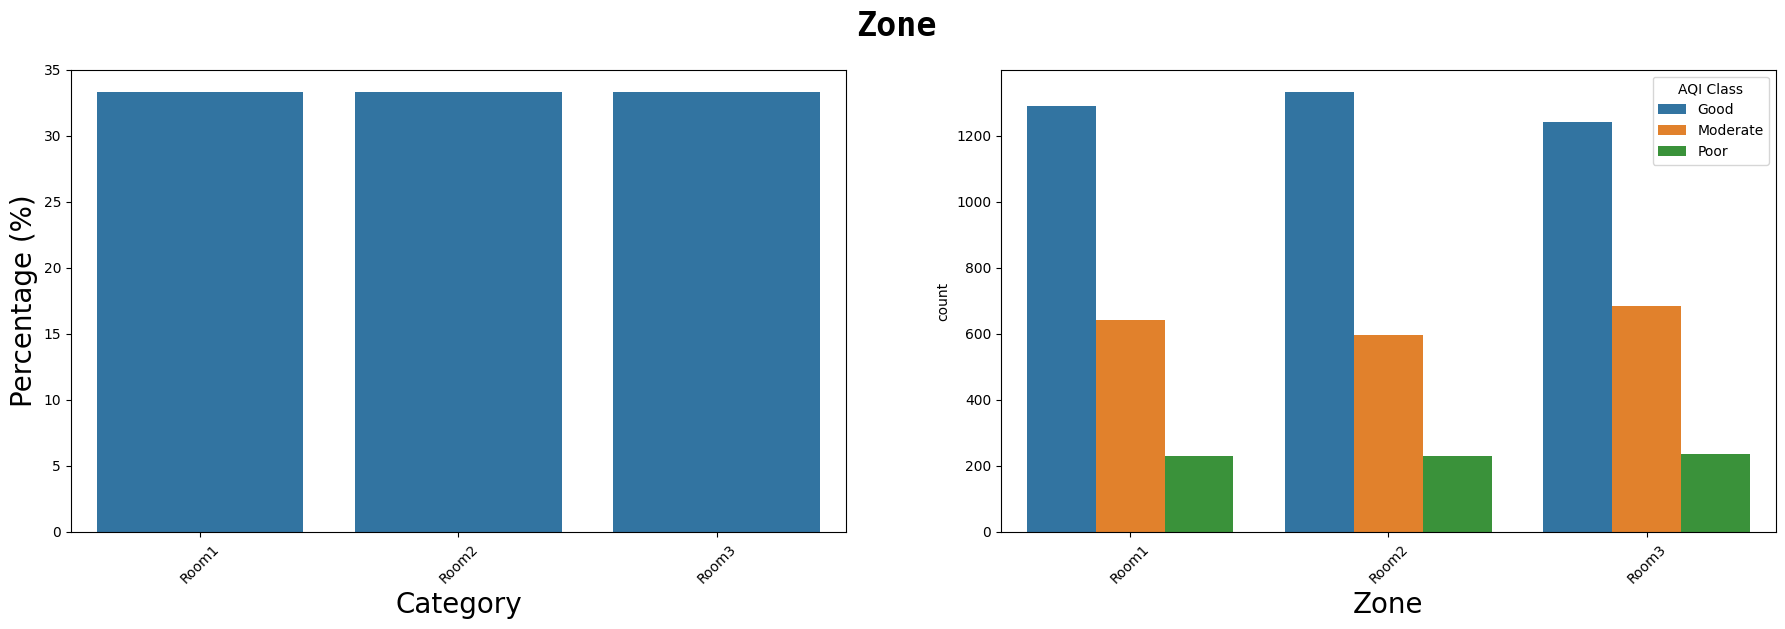

In [102]:
# List of categorical columns in your dataset
categorical_cols = ['Zone'] 

# Run the function for each
for col in categorical_cols:
    Visualization(air_quality, col)

In [103]:
def NumericVisualization(air_quality, col):
    """Plots histogram and boxplot by AQI_Class for numeric columns."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6))
    plt.suptitle(col, fontsize=24, fontname='monospace', weight='bold')
    
    # Left: histogram
    sns.histplot(air_quality[col], bins=30, kde=True, ax=ax1)
    ax1.set_title(f'Distribution of {col}', fontsize=16)
    ax1.set_xlabel(col)
    
    # Right: boxplot by AQI_Class
    sns.boxplot(data=air_quality, x='AQI_Class', y=col, ax=ax2)
    ax2.set_title(f'{col} by AQI Class', fontsize=16)
    
    plt.show()

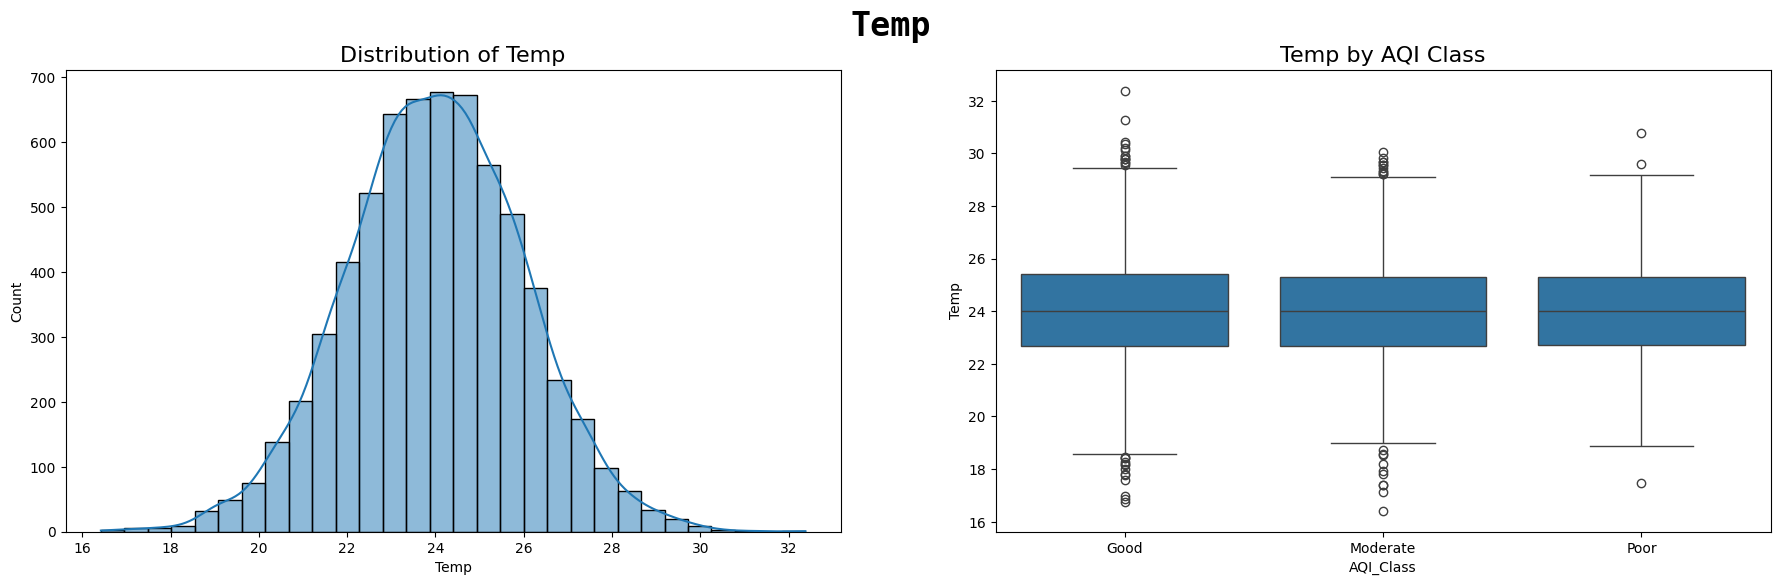

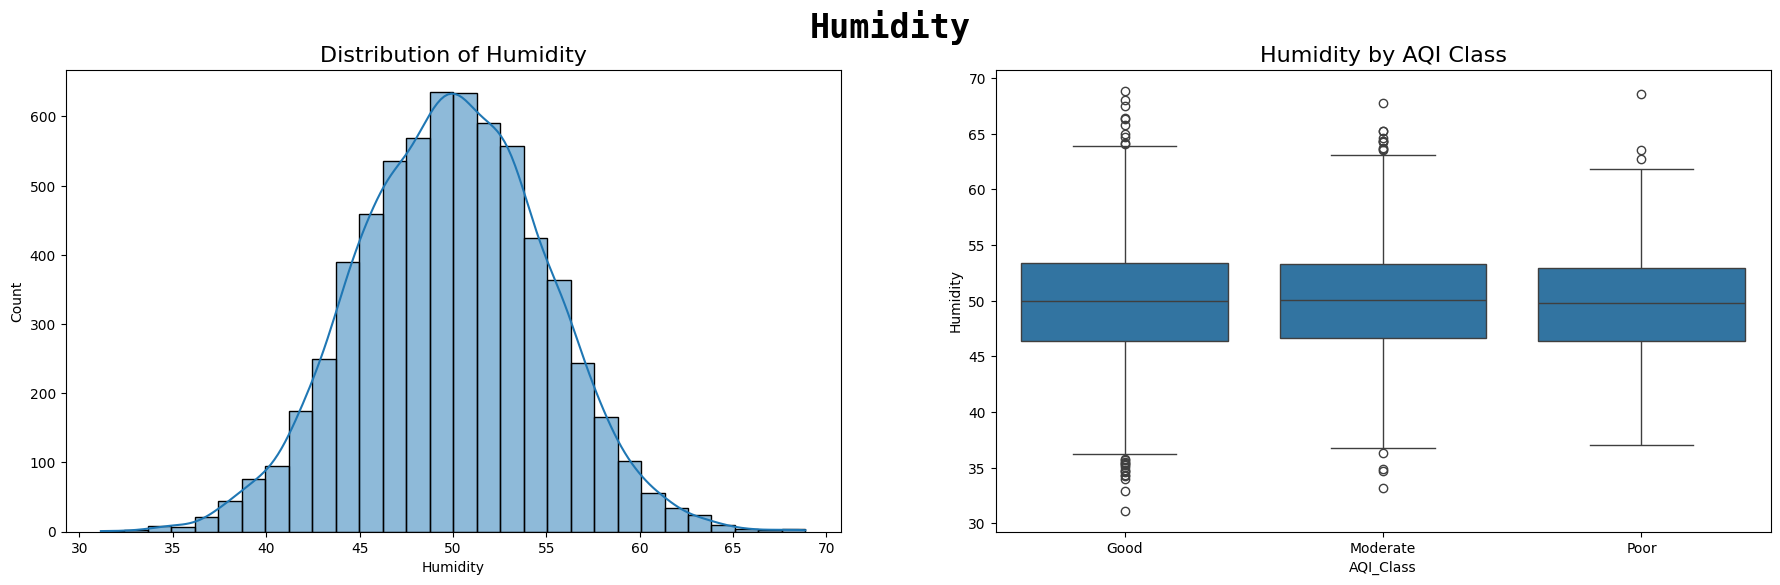

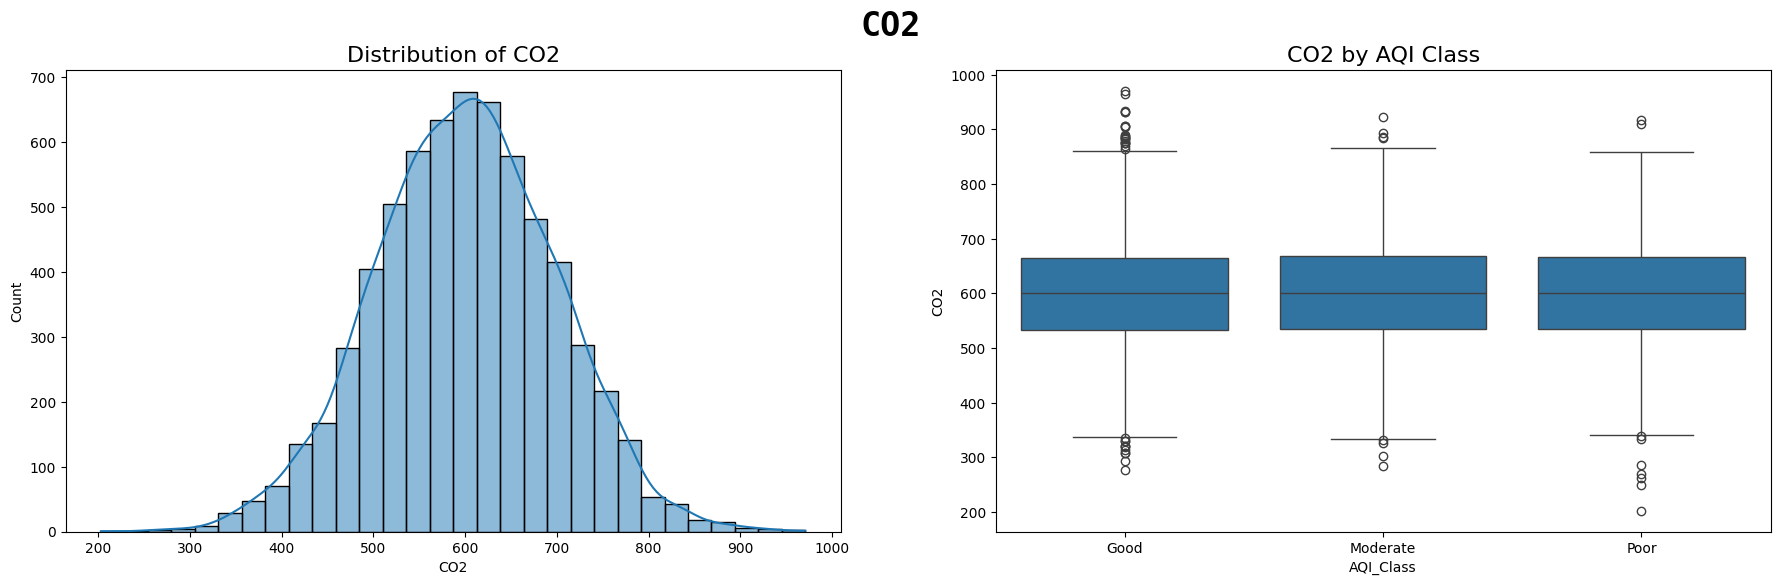

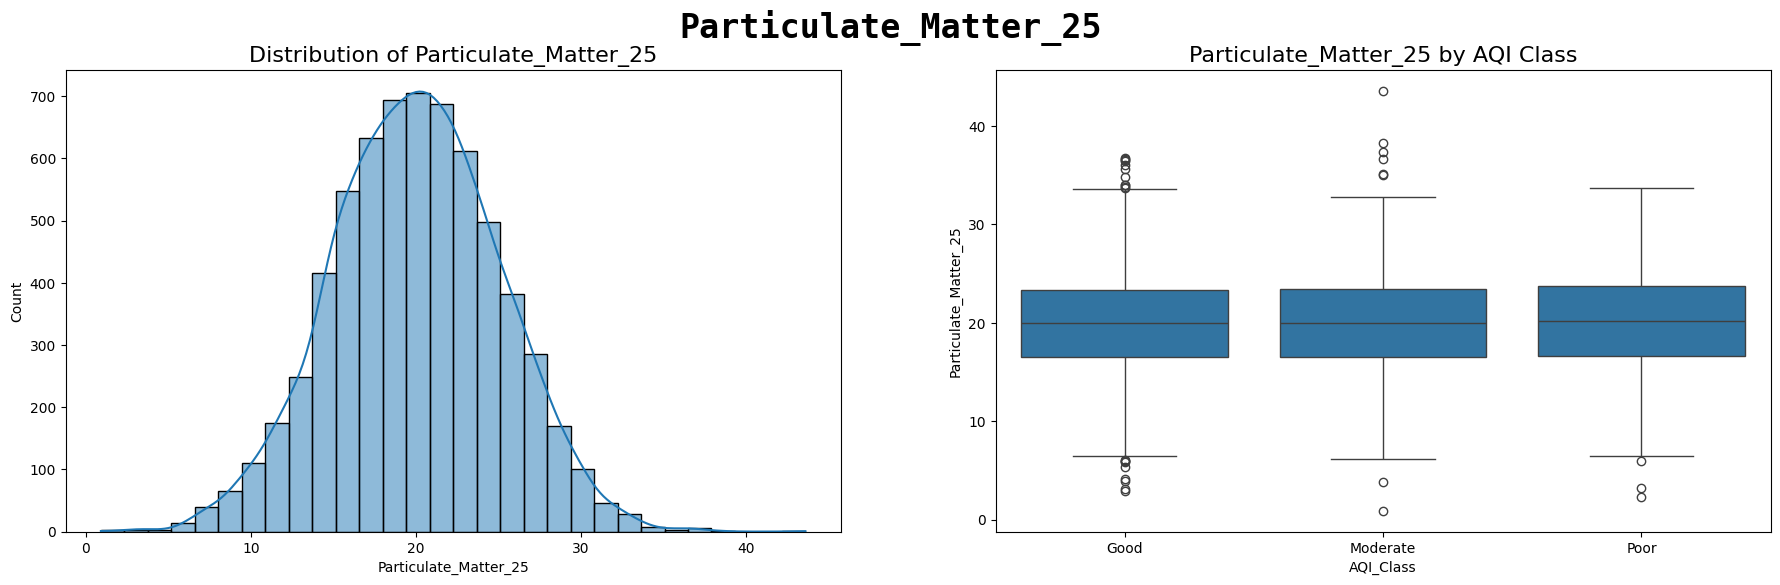

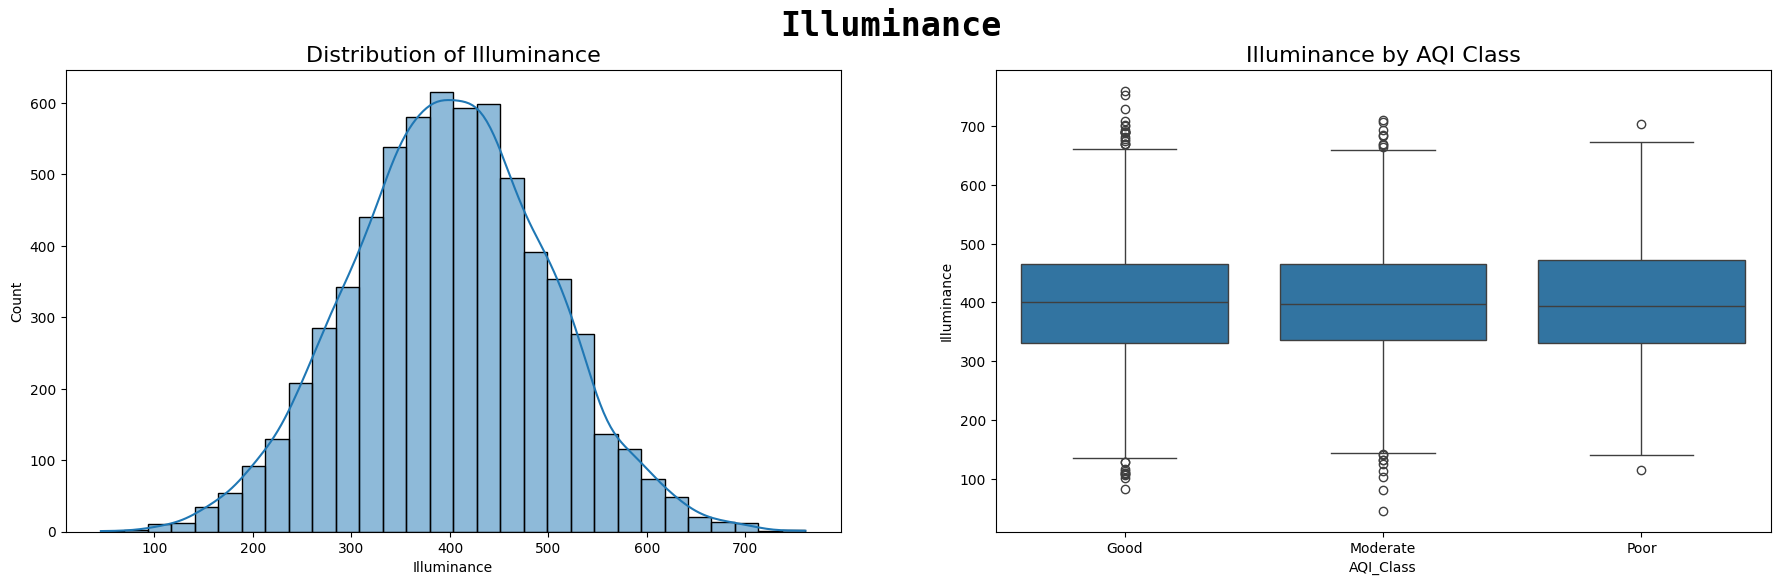

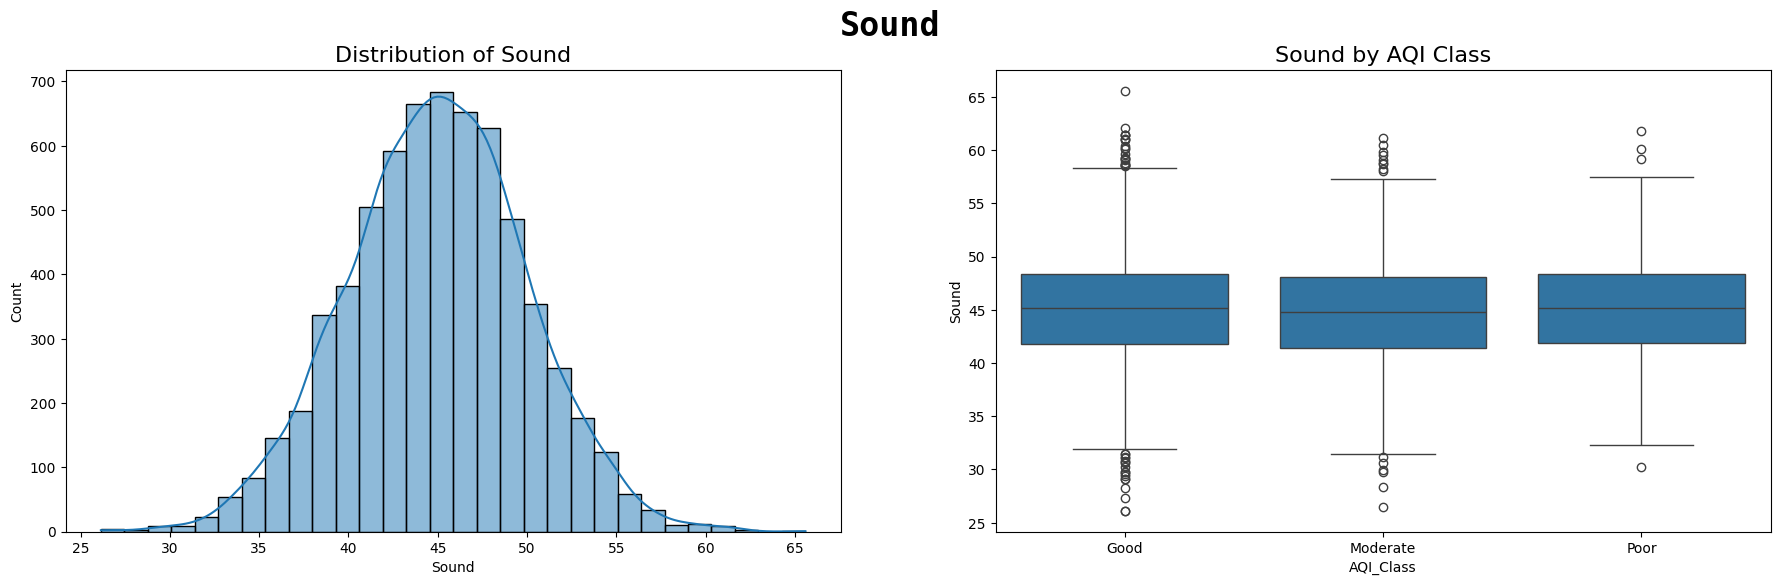

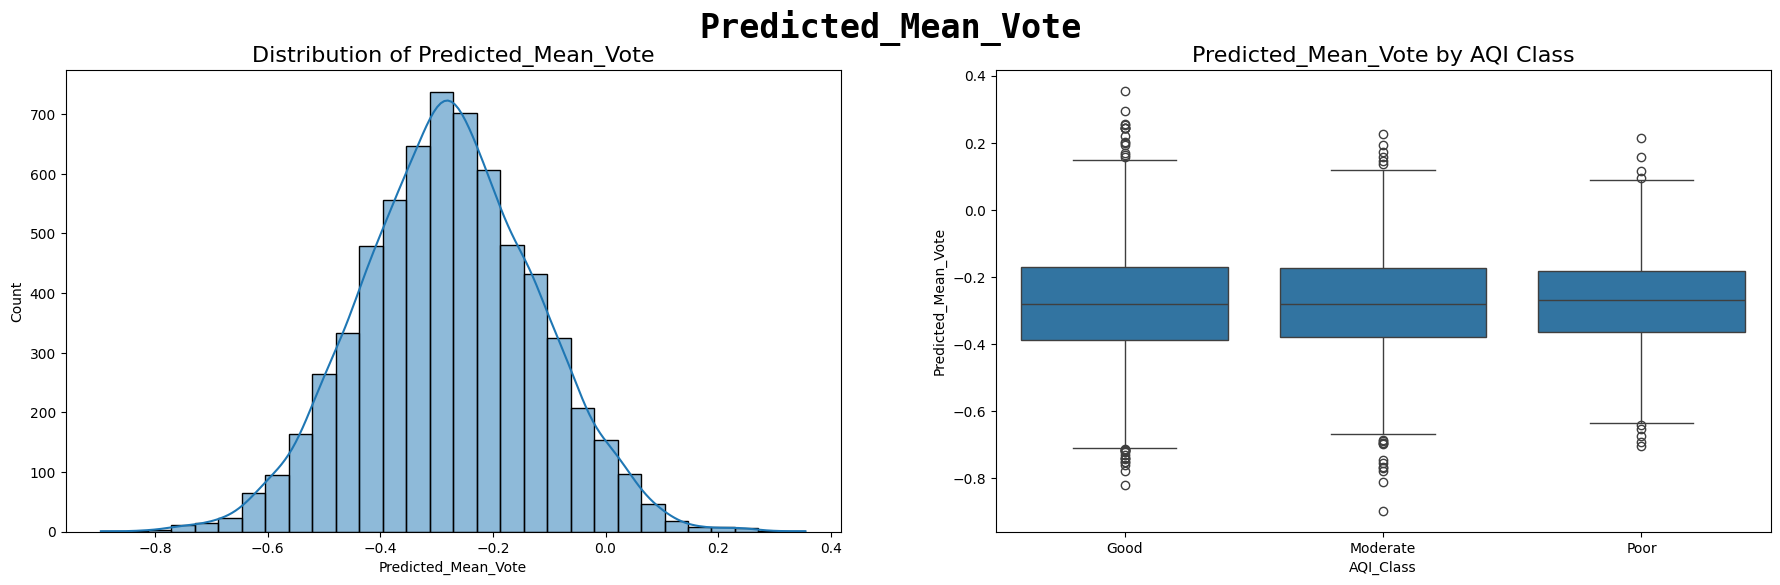

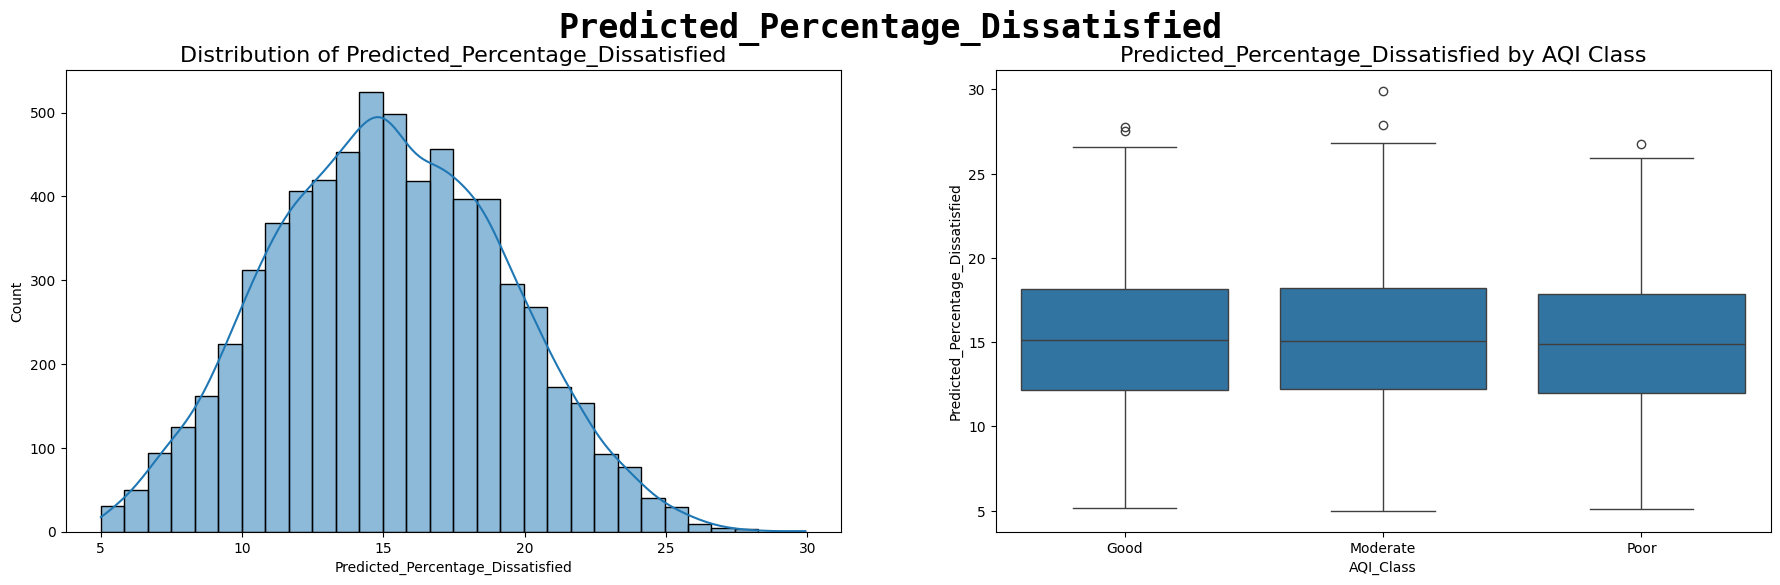

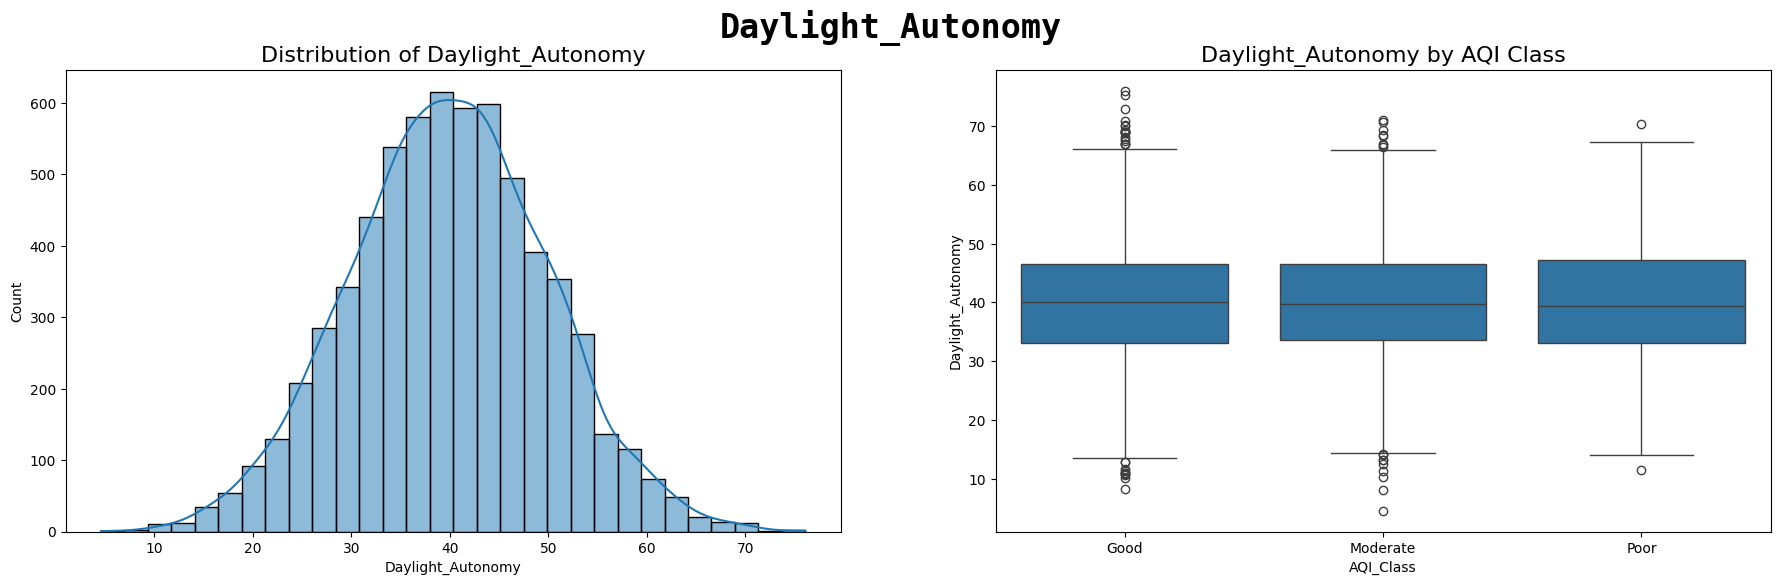

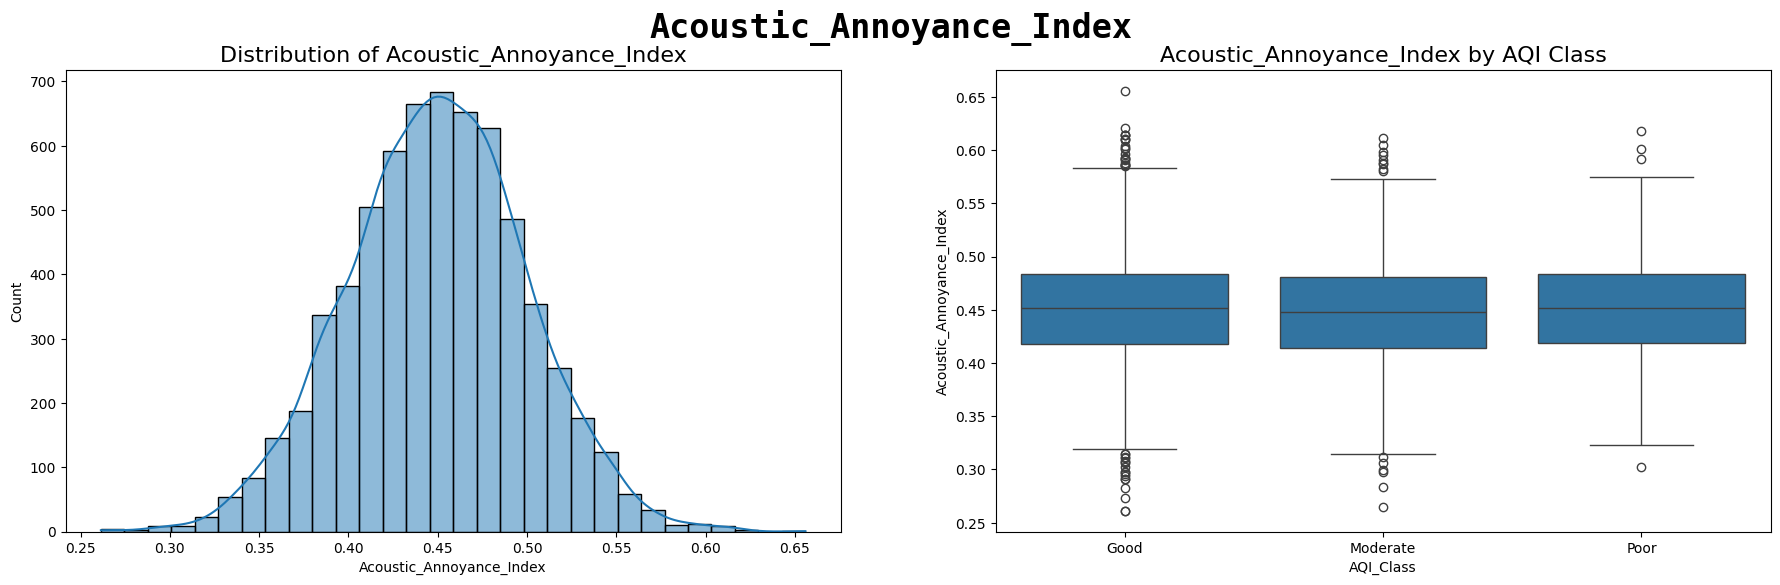

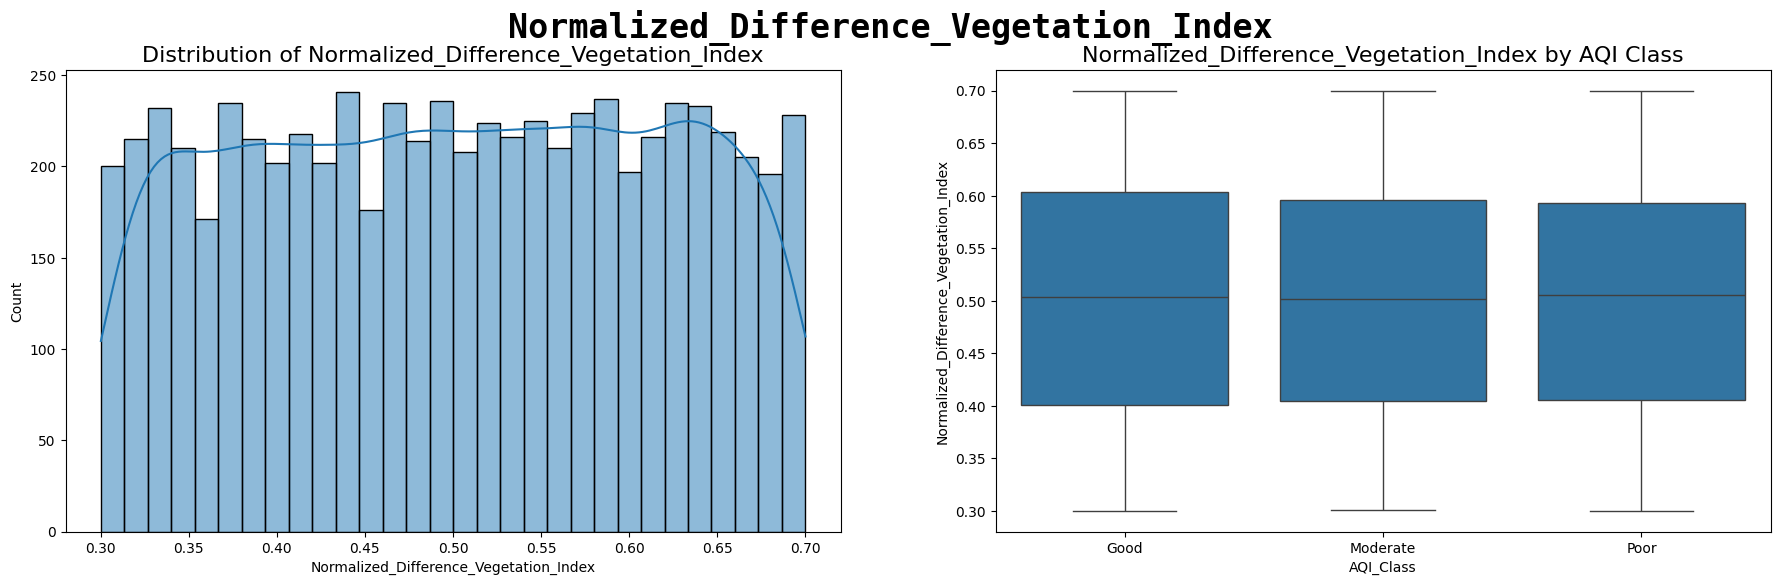

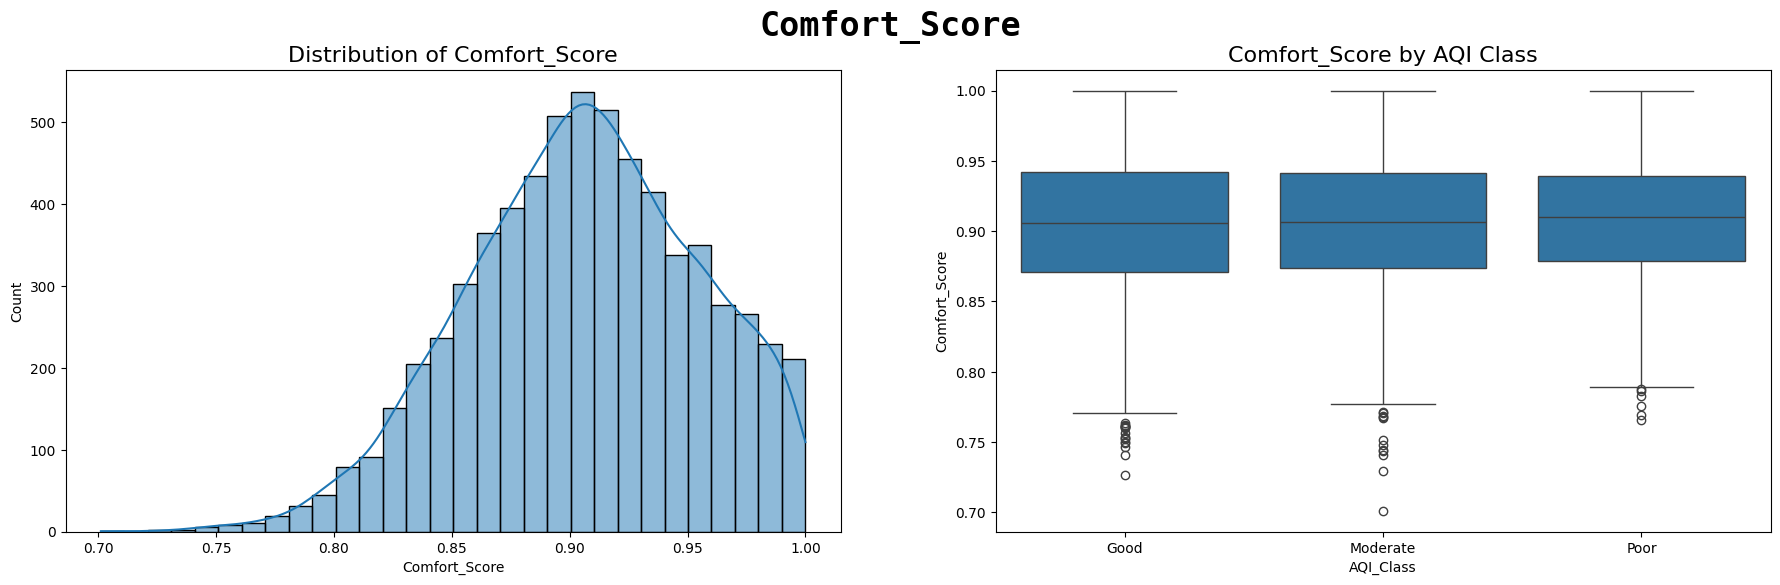

In [104]:
numeric_cols = ['Temp', 'Humidity', 'CO2', 'Particulate_Matter_25', 'Illuminance',
                'Sound', 'Predicted_Mean_Vote', 'Predicted_Percentage_Dissatisfied',
                'Daylight_Autonomy', 'Acoustic_Annoyance_Index',
                'Normalized_Difference_Vegetation_Index', 'Comfort_Score']

for col in numeric_cols:
    NumericVisualization(air_quality, col)

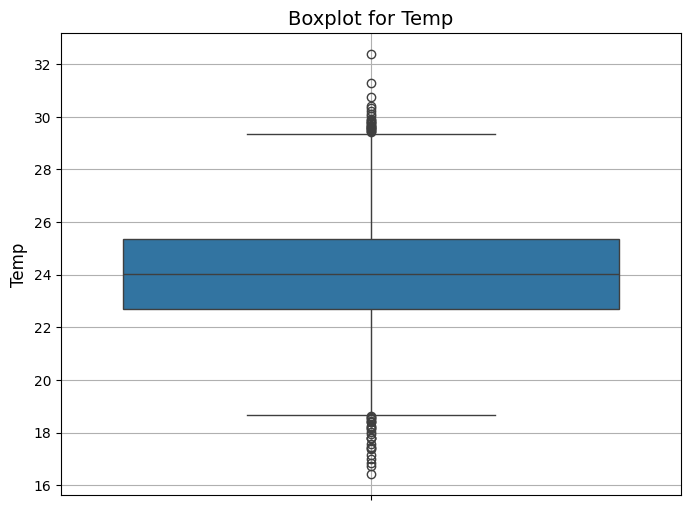

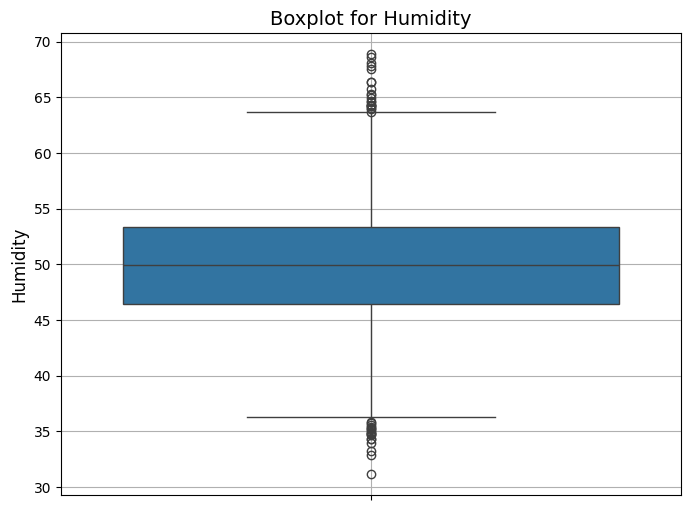

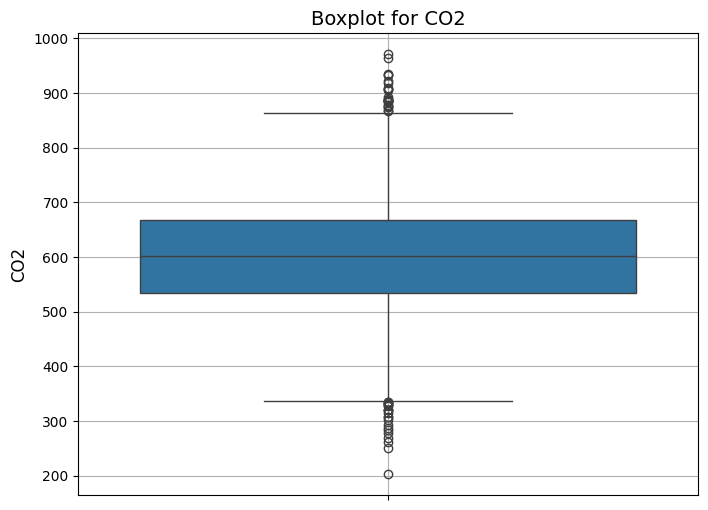

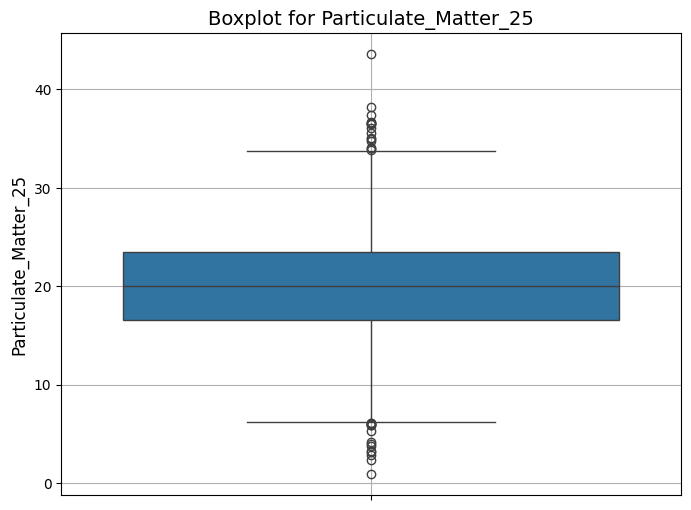

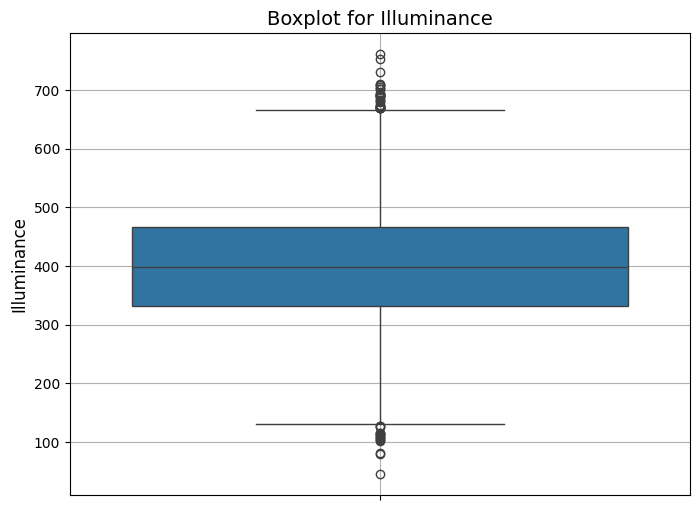

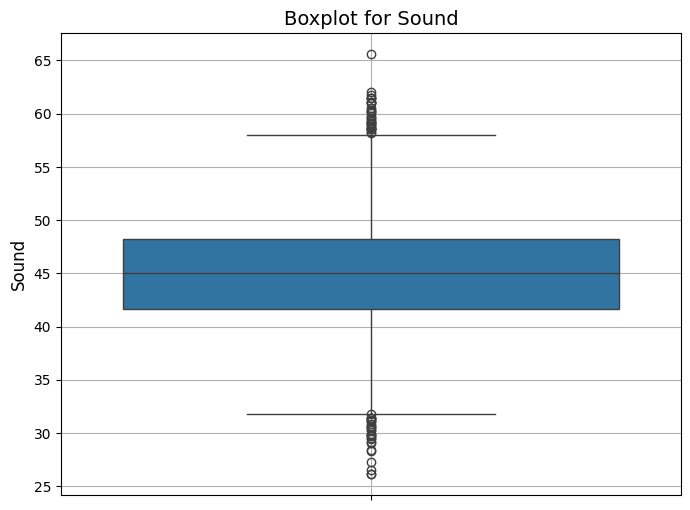

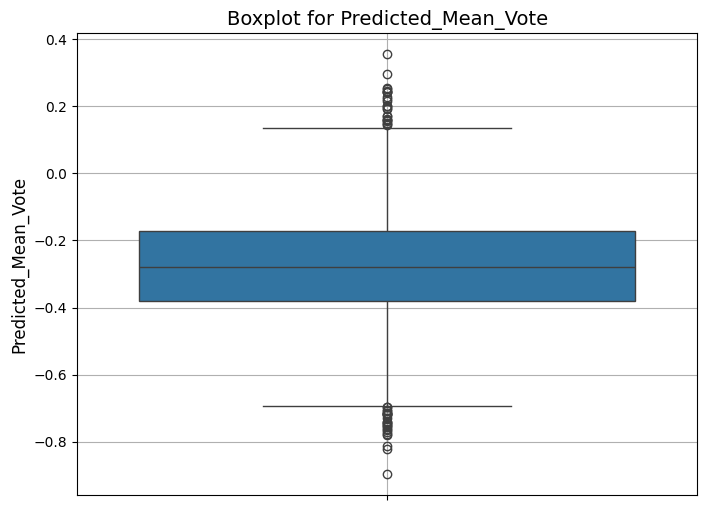

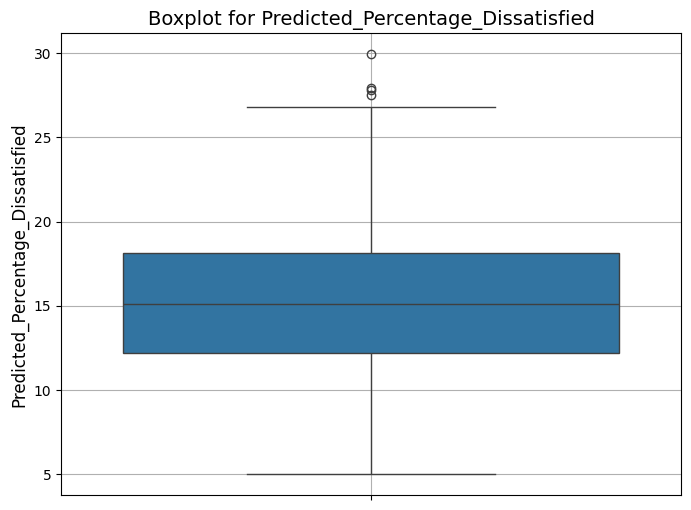

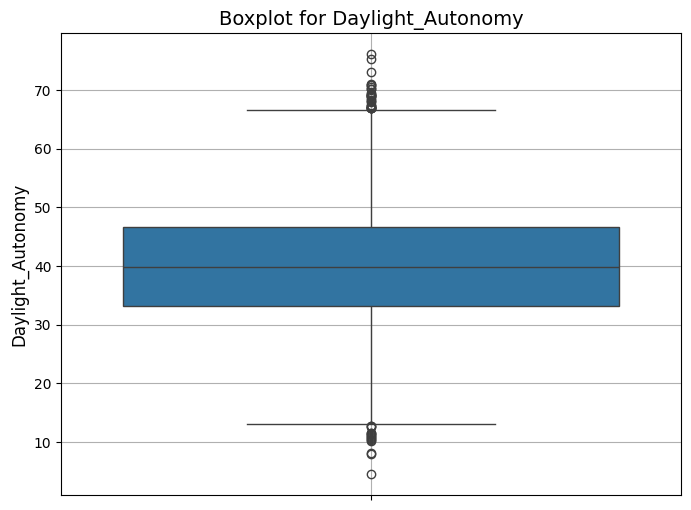

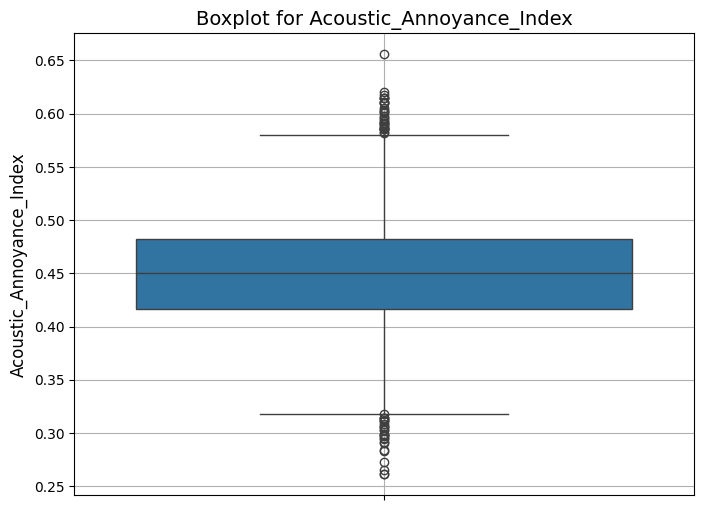

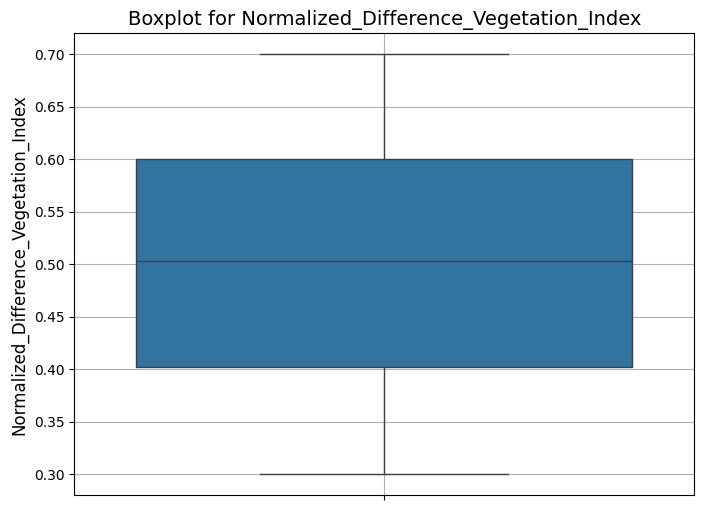

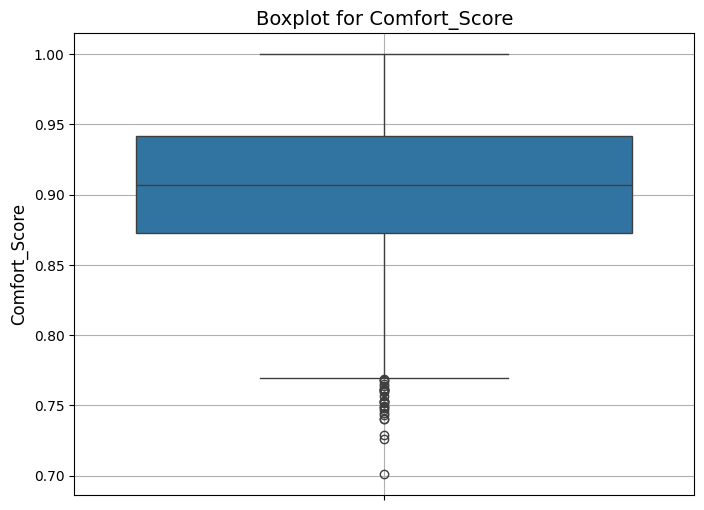

In [105]:
# List of numerical columns to check for outliers
numerical_features = ['Temp', 'Humidity', 'CO2', 'Particulate_Matter_25', 
                      'Illuminance', 'Sound', 'Predicted_Mean_Vote', 
                      'Predicted_Percentage_Dissatisfied', 'Daylight_Autonomy', 
                      'Acoustic_Annoyance_Index', 'Normalized_Difference_Vegetation_Index', 
                      'Comfort_Score']

# Loop through each column to plot a boxplot
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=air_quality, y=feature)
    plt.title(f'Boxplot for {feature}', fontsize=14)
    plt.ylabel(feature, fontsize=12)
    plt.xlabel('')
    plt.grid(True)
    plt.show()

In [106]:
import pandas as pd

# Store results in a list of dictionaries
results = []
for feature in numerical_features:
    n_outliers, lb, ub = count_outliers_iqr(air_quality, feature)
    results.append({
        'Feature': feature,
        'Outlier Count': n_outliers,
        'Lower Bound': round(lb, 2),
        'Upper Bound': round(ub, 2)
    })

# Convert to DataFrame
outlier_table = pd.DataFrame(results)
print(outlier_table)

                                   Feature  Outlier Count  Lower Bound  \
0                                     Temp             50        18.66   
1                                 Humidity             38        36.10   
2                                      CO2             48       335.22   
3                    Particulate_Matter_25             31         6.24   
4                              Illuminance             45       130.84   
5                                    Sound             60        31.75   
6                      Predicted_Mean_Vote             50        -0.69   
7        Predicted_Percentage_Dissatisfied              4         3.29   
8                        Daylight_Autonomy             45        13.08   
9                 Acoustic_Annoyance_Index             60         0.32   
10  Normalized_Difference_Vegetation_Index              0         0.10   
11                           Comfort_Score             27         0.77   

    Upper Bound  
0         29.38  
1

Several environmental features contain a notable number of outliers, including Temp (50), Humidity (38), CO2 (48), Particulate_Matter_25 (31), Illuminance (45), Sound (60), Predicted_Mean_Vote (50), Daylight_Autonomy (45), and Acoustic_Annoyance_Index (60). Predicted_Percentage_Dissatisfied has very few outliers (4), while Normalized_Difference_Vegetation_Index has zero outliers, indicating stable vegetation index values.

We maintain these outliers because they likely represent real, extreme environmental events (e.g., temporary CO₂ spikes, high noise levels due to activity, unusual temperature fluctuations, or sensor anomalies during specific hours). Removing or imputing them would misrepresent actual indoor environmental conditions and reduce the model’s ability to predict rare but important AQI classes (e.g., 'Poor').

The relatively high number of outliers in Sound (60) and Acoustic_Annoyance_Index (60) suggests that acoustic comfort varies significantly across zones and time, which may correlate with AQI class transitions.

Comfort_Score (27 outliers) shows moderate extremity, which is expected given it aggregates multiple environmental inputs.

Therefore, all outliers are retained for training to ensure the model generalizes to real‑world, non‑ideal scenarios.

In [107]:
air_quality.head()

,Timestamp,Sensor_ID,Zone,Temp,Humidity,CO2,Particulate_Matter_25,Illuminance,Sound,Predicted_Mean_Vote,Predicted_Percentage_Dissatisfied,Daylight_Autonomy,Acoustic_Annoyance_Index,Normalized_Difference_Vegetation_Index,Comfort_Score,AQI_Class
0,2024-01-01 00:00:00,S1,Room1,27.025712,47.764121,550.076658,26.502355,374.689685,44.074750,-0.230611,9.612227,37.468969,0.440747,0.590214,0.923130,Good
1,2024-01-01 00:00:00,S2,Room2,25.046120,42.021709,710.304919,15.071982,384.835844,41.317915,-0.130608,14.612158,38.483584,0.413179,0.326628,0.956464,Good
2,2024-01-01 00:00:00,S3,Room3,25.970129,48.071642,579.443408,21.093931,412.939968,37.560666,-0.010097,9.201943,41.293997,0.375607,0.338391,0.996634,Good
3,2024-01-01 01:00:00,S1,Room1,24.184103,53.923401,634.833416,25.220088,370.466555,52.164802,-0.446075,16.921499,37.046655,0.521648,0.595466,0.851308,Good
4,2024-01-01 01:00:00,S2,Room2,25.668486,51.190183,608.683784,8.474166,474.304387,50.166251,-0.168455,8.369094,47.430439,0.501663,0.695018,0.943848,Moderate


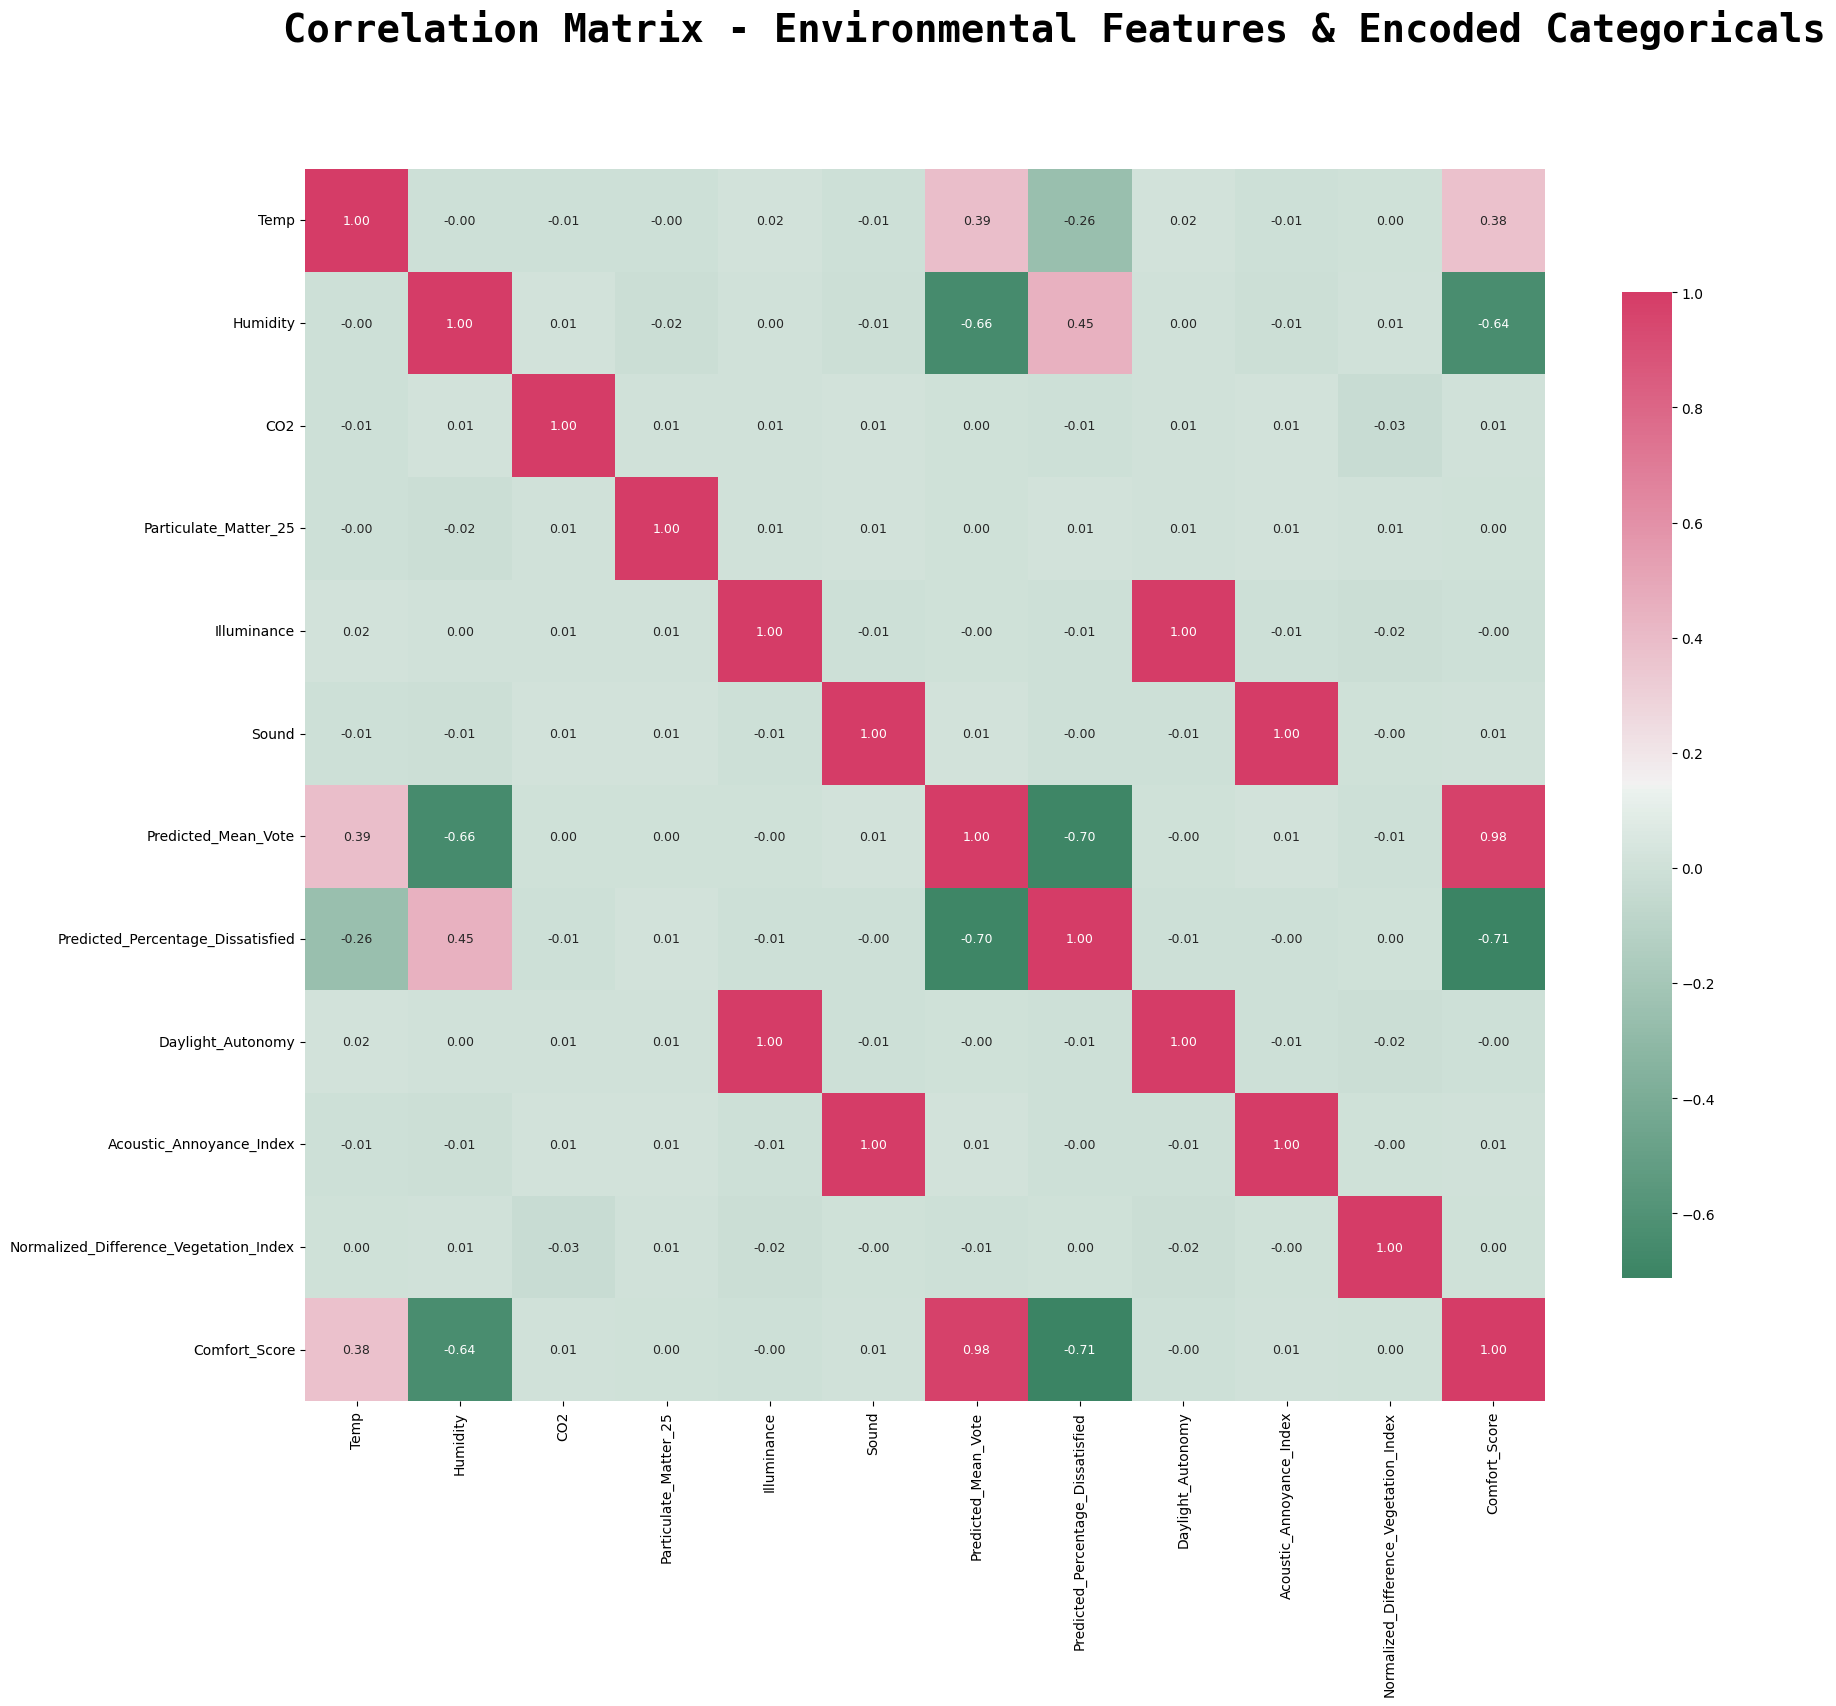

In [109]:
# Select numeric columns including encoded categoricals
numeric_columns = [
    'Temp', 'Humidity', 'CO2', 'Particulate_Matter_25',
    'Illuminance', 'Sound', 'Predicted_Mean_Vote',
    'Predicted_Percentage_Dissatisfied', 'Daylight_Autonomy',
    'Acoustic_Annoyance_Index', 'Normalized_Difference_Vegetation_Index',
    'Comfort_Score'
]

# Plot correlation heatmap
fig = plt.subplots(figsize=(20, 16))
plt.suptitle('Correlation Matrix - Environmental Features & Encoded Categoricals', 
             fontsize=28, fontname='monospace', weight='bold')
cmap = sns.diverging_palette(150, 1, as_cmap=True)

sns.heatmap(air_quality[numeric_columns].corr(), 
            annot=True, cmap=cmap, fmt=".2f", 
            annot_kws={"size": 9}, 
            cbar_kws={"shrink": 0.8})

plt.show()

In [110]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [111]:
from sklearn.preprocessing import LabelEncoder

# Dictionary to store label encoders for each categorical column
label = {}

# Apply LabelEncoder to all object-type columns (categorical)
for col in air_quality.select_dtypes(include=['object']).columns:
    label[col] = LabelEncoder()
    air_quality[col + '_Encoded'] = label[col].fit_transform(air_quality[col])
    
    # Optional: replace original column (if you don't want to keep text)
    # air_quality[col] = label[col].fit_transform(air_quality[col])

# Check the result
print(air_quality[[col for col in air_quality.columns if 'Encoded' in col]].head())

   Sensor_ID_Encoded  Zone_Encoded  AQI_Class_Encoded
0                  0             0                  0
1                  1             1                  0
2                  2             2                  0
3                  0             0                  0
4                  1             1                  1


In [113]:
air_quality.head(25)

,Timestamp,Sensor_ID,Zone,Temp,Humidity,CO2,Particulate_Matter_25,Illuminance,Sound,Predicted_Mean_Vote,Predicted_Percentage_Dissatisfied,Daylight_Autonomy,Acoustic_Annoyance_Index,Normalized_Difference_Vegetation_Index,Comfort_Score,AQI_Class,Sensor_ID_Encoded,Zone_Encoded,AQI_Class_Encoded
0,2024-01-01 00:00:00,S1,Room1,27.025712,47.764121,550.076658,26.502355,374.689685,44.074750,-0.230611,9.612227,37.468969,0.440747,0.590214,0.923130,Good,0,0,0
1,2024-01-01 00:00:00,S2,Room2,25.046120,42.021709,710.304919,15.071982,384.835844,41.317915,-0.130608,14.612158,38.483584,0.413179,0.326628,0.956464,Good,1,1,0
2,2024-01-01 00:00:00,S3,Room3,25.970129,48.071642,579.443408,21.093931,412.939968,37.560666,-0.010097,9.201943,41.293997,0.375607,0.338391,0.996634,Good,2,2,0
3,2024-01-01 01:00:00,S1,Room1,24.184103,53.923401,634.833416,25.220088,370.466555,52.164802,-0.446075,16.921499,37.046655,0.521648,0.595466,0.851308,Good,0,0,0
4,2024-01-01 01:00:00,S2,Room2,25.668486,51.190183,608.683784,8.474166,474.304387,50.166251,-0.168455,8.369094,47.430439,0.501663,0.695018,0.943848,Moderate,1,1,1
5,2024-01-01 01:00:00,S3,Room3,24.381559,47.754255,664.752851,22.338904,614.199028,44.932711,-0.188740,8.774797,61.419903,0.449327,0.314814,0.937087,Moderate,2,2,1
6,2024-01-01 02:00:00,S1,Room1,24.468516,58.113198,618.234266,22.970073,436.373388,48.095827,-0.435761,20.715228,43.637339,0.480958,0.499172,0.854746,Good,0,0,0
7,2024-01-01 02:00:00,S2,Room2,24.089317,45.308605,597.854488,16.017193,372.023878,46.309755,-0.160085,13.201709,37.202388,0.463098,0.416983,0.946638,Good,1,1,0
8,2024-01-01 02:00:00,S3,Room3,20.730689,52.298672,459.051654,25.563639,402.027425,42.787354,-0.548217,22.964337,40.202742,0.427874,0.696439,0.817261,Moderate,2,2,1
9,2024-01-01 03:00:00,S1,Room1,23.425094,53.050313,540.096374,15.232228,447.704086,41.934151,-0.518806,24.376120,44.770409,0.419342,0.507694,0.827065,Good,0,0,0


In [114]:
# Drop original object columns (keep encoded versions)
air_quality_clean = air_quality.drop(['Sensor_ID', 'Zone', 'AQI_Class'], axis=1)

# Optionally drop Timestamp if not used as a feature
if 'Timestamp' in air_quality_clean.columns:
    air_quality_clean = air_quality_clean.drop('Timestamp', axis=1)

# Verify no object columns remain
print(air_quality_clean.dtypes)

Temp                                      float64
Humidity                                  float64
CO2                                       float64
Particulate_Matter_25                     float64
Illuminance                               float64
Sound                                     float64
Predicted_Mean_Vote                       float64
Predicted_Percentage_Dissatisfied         float64
Daylight_Autonomy                         float64
Acoustic_Annoyance_Index                  float64
Normalized_Difference_Vegetation_Index    float64
Comfort_Score                             float64
Sensor_ID_Encoded                           int32
Zone_Encoded                                int32
AQI_Class_Encoded                           int32
dtype: object
